#분석 배경

*   기본적인 대중교통 이용추이 분석
*   따릉이의 신규 가입자 및 이용도 추가 분석



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 분석환경 설정하기
import os
# wd = "지정하고자 하는 경로"
os.getcwd() # 현재 작업 경로 출력
os.chdir('/content/drive/MyDrive/data_team_project_01/00. data')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
!pip install -q koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 34.4 MB/s eta 0:00:00


In [ ]:
import koreanize_matplotlib

## 대중교통 이용현황 분석

*   버스, 지하철, 택시, 따릉이의 이용건수 비교
*   기간은 2024~2026/07월까지

In [ ]:
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

PROJECT_DIR = '/content/drive/MyDrive/data_team_project_01'
RESEARCH_DIR = os.path.join(PROJECT_DIR, '01. 리서치')
DATA_DIR = os.path.join(PROJECT_DIR, '00. data')

os.path.isdir(RESEARCH_DIR), os.path.isdir(DATA_DIR)  # 둘 다 True가 나와야 경로가 맞는 것

(True, True)

In [ ]:
traffic_files = {
    2024: os.path.join(RESEARCH_DIR, '서울시_교통현황_2024년_월간.csv'),
    2025: os.path.join(RESEARCH_DIR, '서울시_교통현황_2025년_월간.csv'),
    2026: os.path.join(RESEARCH_DIR, '서울시_교통현황_2026년_1-7월_월간.csv'),
}

all_df = pd.concat(
    [pd.read_csv(p, encoding='utf-8-sig') for p in traffic_files.values()],
    ignore_index=True,
)

usage = all_df[(all_df['지표'] == '일평균 이용건수(건)') & (all_df['구분'] == '전체')].copy()
usage = usage.sort_values(['연도', '월']).reset_index(drop=True)
usage['연월'] = usage['연도'].astype(str) + '-' + usage['월'].astype(str).str.zfill(2)

modes = ['버스', '지하철', '택시', '따릉이']
usage[['연월'] + modes].head()


,연월,버스,지하철,택시,따릉이
0,2024-01,4169171.0,5574764.0,599931.0,61976.0
1,2024-02,4132864.0,5461686.0,457998.0,67742.0
2,2024-03,4456111.0,5924368.0,642593.0,98403.0
3,2024-04,4681539.0,6123034.0,731631.0,148674.0
4,2024-05,4631565.0,6013766.0,725208.0,149744.0


In [ ]:
x = np.arange(len(usage))  # len(df)는 df의 row의 갯수를 표출 2024년 1월부터 2026년 7월까지 31개의 행을 각 월을 x축으로 잡는다는 뜻(31칸)

for m in modes:
    y = usage[m].values
    slope, intercept = np.polyfit(x, y, 1)
    print(f'{m:6s}: 기울기(월평균 변화량) = {slope:+,.0f}건/월,  절편 = {intercept:,.0f}')

버스    : 기울기(월평균 변화량) = +11,918건/월,  절편 = 4,441,524
지하철   : 기울기(월평균 변화량) = +34,203건/월,  절편 = 5,610,348
택시    : 기울기(월평균 변화량) = +2,672건/월,  절편 = 673,384
따릉이   : 기울기(월평균 변화량) = -383건/월,  절편 = 111,401


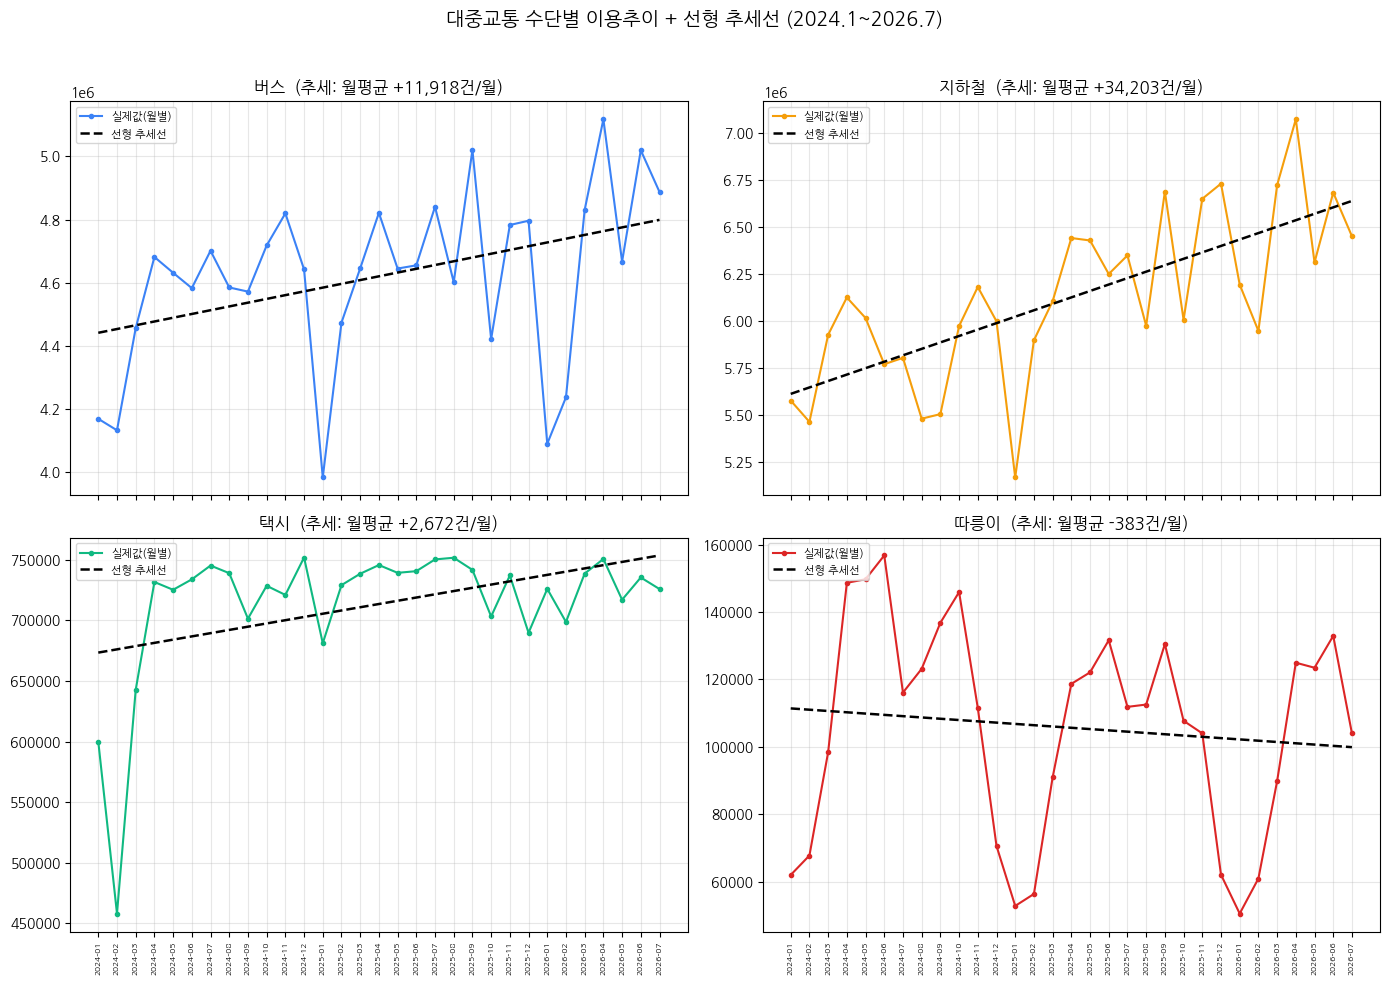

In [ ]:
colors = {'버스': '#3b82f6', '지하철': '#f59e0b', '택시': '#10b981', '따릉이': '#dc2626'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

for ax, m in zip(axes.flat, modes):
    y = usage[m].values
    ax.plot(usage['연월'], y, marker='o', markersize=3, color=colors[m], linewidth=1.5, label='실제값(월별)')

    slope, intercept = np.polyfit(x, y, 1)
    trend = slope * x + intercept
    ax.plot(usage['연월'], trend, linestyle='--', color='black', linewidth=1.8, label='선형 추세선')

    sign = '+' if slope >= 0 else ''
    ax.set_title(f'{m}  (추세: 월평균 {sign}{slope:,.0f}건/월)')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=90, labelsize=6)

fig.suptitle('대중교통 수단별 이용추이 + 선형 추세선 (2024.1~2026.7)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 따릉이 신규 가입자 추이

*   월별 신규가입자 CSV 5개(24.1~26.6월)를 이어붙여서 월별 총 가입건수를 뽑음
*   이용추이(`usage`)의 따릉이 컬럼과 합쳐서 "가입자가 줄면 이용량도 같이 줄어드는지" 비교
*   전년동월 대비 증감률(%)도 같이 계산해서 가입자 감소가 이용량 감소보다 더 가파른지 확인


In [ ]:
# 신규가입자 CSV는 회원구분·연령대·성별별로 잘게 나뉘어 있고, 인코딩도 cp949(EUC-KR)라 다른 파일들과 다름
signup_filenames = [
    '서울특별시 공공자전거 신규가입자 정보(월별)_24.1-6.csv',
    '서울특별시 공공자전거 신규가입자 정보(월별)_24.7-12.csv',
    '서울특별시 공공자전거 신규가입자 정보(월별)_25.1-6.csv',
    '서울특별시 공공자전거 신규가입자 정보(월별)_25.7-12.csv',
    '서울특별시 공공자전거 신규가입자 정보(월별)_26.1-6.csv',
]

# 파일을 00. data 바로 아래 또는 00. data/old 아래, 둘 중 있는 곳에서 찾음
# (다른 주제(버스) 자료가 00. data에 새로 들어오면서 예전 따릉이 원본을 old 폴더로 옮겨둔 경우를 대비)
SIGNUP_CANDIDATE_DIRS = [DATA_DIR, os.path.join(DATA_DIR, 'old')]

def find_file(name, candidates):
    for d in candidates:
        p = os.path.join(d, name)
        if os.path.isfile(p):
            return p
    raise FileNotFoundError(f'{name} 을(를) 찾을 수 없습니다 — 00. data 폴더 구조를 확인하세요')

signup_files = [find_file(name, SIGNUP_CANDIDATE_DIRS) for name in signup_filenames]

signup_raw = pd.concat(
    [pd.read_csv(p, encoding='cp949') for p in signup_files],
    ignore_index=True,
)
signup_raw.head()

,가입년월,회원구분,연령대,성별,가입건수
0,202401,회원-내국인,~10대,F,909
1,202401,회원-내국인,20대,F,1896
2,202401,회원-내국인,30대,F,1073
3,202401,회원-내국인,40대,F,807
4,202401,회원-내국인,50대,F,526


In [ ]:
# 회원구분·연령대·성별 구분 없이, '그 달에 가입한 사람 수 총합'만 필요하므로 가입년월로 묶어서 합산
signup_monthly = signup_raw.groupby('가입년월')['가입건수'].sum().reset_index()
signup_monthly['연도'] = signup_monthly['가입년월'] // 100 # "202401"형식으로 날짜가 지정되어 있어서 100으로 나눈 몫은 "2024" 즉, 년만 남음
signup_monthly['월'] = signup_monthly['가입년월'] % 100 # "202401"형식으로 날짜가 지정되어 있어서 100으로 나눈 나머지는 "1" 즉, 월만 남음
signup_monthly = signup_monthly.sort_values(['연도', '월']).reset_index(drop=True)
signup_monthly['연월'] = signup_monthly['연도'].astype(str) + '-' + signup_monthly['월'].astype(str).str.zfill(2)

signup_monthly[['연월', '가입건수']].head()

,연월,가입건수
0,2024-01,14081
1,2024-02,41162
2,2024-03,52195
3,2024-04,82167
4,2024-05,66090


In [ ]:
# usage의 따릉이 이용건수와 연도·월 기준으로 merge
# how='inner'로 두 데이터가 겹치는 구간(2024.1~2026.6)만 남김 — usage는 2026.7까지 있지만 가입자 데이터는 2026.6까지뿐
signup_usage = pd.merge(
    signup_monthly[['연도', '월', '연월', '가입건수']],
    usage[['연도', '월', '따릉이']],
    on=['연도', '월'],
    how='inner',
)
signup_usage.head()

,연도,월,연월,가입건수,따릉이
0,2024,1,2024-01,14081,61976.0
1,2024,2,2024-02,41162,67742.0
2,2024,3,2024-03,52195,98403.0
3,2024,4,2024-04,82167,148674.0
4,2024,5,2024-05,66090,149744.0


In [ ]:
# 신규 가입건수에도 앞서(cell 8) 이용추이에 썼던 것과 같은 방식으로 선형 추세선을 구함
x_signup = np.arange(len(signup_usage))  # 2024.1~2026.6, 30개월치 인덱스

slope_signup, intercept_signup = np.polyfit(x_signup, signup_usage['가입건수'].values, 1)
print(f'신규 가입건수: 기울기(월평균 변화량) = {slope_signup:+,.0f}건/월,  절편 = {intercept_signup:,.0f}')

신규 가입건수: 기울기(월평균 변화량) = -569건/월,  절편 = 44,642


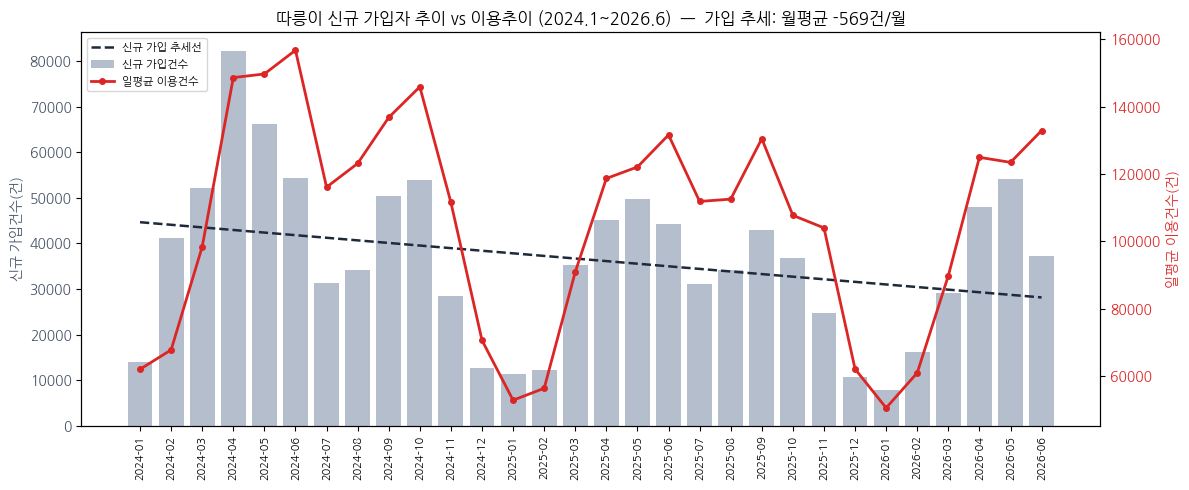

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(signup_usage['연월'], signup_usage['가입건수'], color='#94A3B8', alpha=0.7, label='신규 가입건수')

trend_signup = slope_signup * x_signup + intercept_signup
ax1.plot(signup_usage['연월'], trend_signup, linestyle='--', color='#1E293B', linewidth=1.8, label='신규 가입 추세선')

ax1.set_ylabel('신규 가입건수(건)', color='#475569')
ax1.tick_params(axis='y', labelcolor='#475569')
ax1.tick_params(axis='x', rotation=90, labelsize=8)

ax2 = ax1.twinx()
ax2.plot(signup_usage['연월'], signup_usage['따릉이'], color=colors['따릉이'], marker='o', markersize=4,
         linewidth=2, label='일평균 이용건수')
ax2.set_ylabel('일평균 이용건수(건)', color=colors['따릉이'])
ax2.tick_params(axis='y', labelcolor=colors['따릉이'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

sign = '+' if slope_signup >= 0 else ''
ax1.set_title(f'따릉이 신규 가입자 추이 vs 이용추이 (2024.1~2026.6)  —  가입 추세: 월평균 {sign}{slope_signup:,.0f}건/월')
plt.tight_layout()
plt.show()

# 시간에 따른 따릉이 이용추이 분석

*   월별 / 계절별 이용 패턴
*   평일·주말 × 시간대별 이용 패턴
*   날씨에 따른 이용건수 변화


## 기본 전처리
*   공공자전거 이용현황 2024년부터 2026.06까지 전처리
*   단순 추합으로는 용량이 비대해져 그에 맞는 전처리 필요


In [ ]:
import pandas as pd, os, unicodedata

def norm(s):
    return unicodedata.normalize('NFC', s)

months = pd.period_range('2024-01', '2026-06', freq='M')
expected = {m.strftime('%Y%m'): f'서울특별시 공공자전거 이용정보(시간대별)_{m.strftime("%Y%m")}.csv'
            for m in months}

all_files_norm = {norm(f): f for f in os.listdir(DATA_DIR)}

files, missing = [], []
for ym, name in expected.items():
    real_name = all_files_norm.get(norm(name))
    if real_name is None:
        missing.append(ym)
        continue
    path = os.path.join(DATA_DIR, real_name)
    size_mb = os.path.getsize(path) / 1e6
    if size_mb < 10:
        print(f'⚠ {ym}: 파일은 있는데 용량이 {size_mb:.1f}MB — 확인 필요 (다운로드 깨졌을 수도)')
    files.append(path)

if missing:
    raise FileNotFoundError(f'다음 월 파일을 못 찾음: {missing}')
print(f'{len(files)}개월 모두 정상 확인됨 (2024-01 ~ 2026-06)')

30개월 모두 정상 확인됨 (2024-01 ~ 2026-06)


In [ ]:
USE_COLS = ['대여일자', '대여시간', '이용건수']
ENCODING = 'cp949'

agg_list, qa_log = [], []

for i, fp in enumerate(files, 1):
    fname = os.path.basename(fp)
    print(f'[{i}/{len(files)}] {fname}')
    n_rows = 0
    n_na = pd.Series(0, index=USE_COLS)
    n_hour_bad = n_count_bad = n_dup = 0
    partial = []

    # 컬럼 지정 없이 전체 컬럼을 읽어서 '행 전체'가 똑같은지로 중복 판단
    for chunk in pd.read_csv(fp, encoding=ENCODING, chunksize=500_000):
        n_rows += len(chunk)
        n_na += chunk[USE_COLS].isna().sum()
        n_hour_bad += (~chunk['대여시간'].between(0, 23)).sum()
        n_count_bad += (chunk['이용건수'] < 0).sum()
        n_dup += chunk.duplicated().sum()   # ← 전체 컬럼 기준 완전 중복만 카운트
        partial.append(chunk.groupby(['대여일자', '대여시간'], as_index=False)['이용건수'].sum())

    agg_list.append(pd.concat(partial).groupby(['대여일자', '대여시간'], as_index=False)['이용건수'].sum())
    qa_log.append({'파일': fname, '행수': n_rows,
        '결측_날짜': n_na['대여일자'], '결측_시간': n_na['대여시간'], '결측_이용건수': n_na['이용건수'],
        '시간범위이상': n_hour_bad, '이용건수음수': n_count_bad, '완전중복행': n_dup})

[1/30] 서울특별시 공공자전거 이용정보(시간대별)_202401.csv
[2/30] 서울특별시 공공자전거 이용정보(시간대별)_202402.csv
[3/30] 서울특별시 공공자전거 이용정보(시간대별)_202403.csv
[4/30] 서울특별시 공공자전거 이용정보(시간대별)_202404.csv
[5/30] 서울특별시 공공자전거 이용정보(시간대별)_202405.csv
[6/30] 서울특별시 공공자전거 이용정보(시간대별)_202406.csv
[7/30] 서울특별시 공공자전거 이용정보(시간대별)_202407.csv
[8/30] 서울특별시 공공자전거 이용정보(시간대별)_202408.csv
[9/30] 서울특별시 공공자전거 이용정보(시간대별)_202409.csv
[10/30] 서울특별시 공공자전거 이용정보(시간대별)_202410.csv
[11/30] 서울특별시 공공자전거 이용정보(시간대별)_202411.csv
[12/30] 서울특별시 공공자전거 이용정보(시간대별)_202412.csv
[13/30] 서울특별시 공공자전거 이용정보(시간대별)_202501.csv
[14/30] 서울특별시 공공자전거 이용정보(시간대별)_202502.csv
[15/30] 서울특별시 공공ᄌ

In [ ]:
qa_df = pd.DataFrame(qa_log)
qa_df

,파일,행수,결측_날짜,결측_시간,결측_이용건수,시간범위이상,이용건수음수,완전중복행
0,서울특별시 공공자전거 이용정보(시간대...,1860884,0,0,0,0,0,0
1,서울특별시 공공자전거 이용정보(시간대...,1899823,0,0,0,0,0,0
2,서울특별시 공공자전거 이용정보(시간대...,2885557,0,0,0,0,0,0
3,서울특별시 공공자전거 이용정보(시간대...,4124887,0,0,0,0,0,0
4,서울특별시 공공자전거 이용정보(시간대...,4267449,0,0,0,0,0,0
5,서울특별시 공공자전거 이용정보(시간대...,4331051,0,0,0,0,0,0
6,서울특별시 공공자전거 이용정보(시간대...,3374218,0,0,0,0,0,0
7,서울특별시 공공자전거 이용정보(시간대...,3624189,0,0,0,0,0,0
8,서울특별시 공공자전거 이용정보(시간대...,3806006,0,0,0,0,0,0
9,서울특별시 공공자전거 이용정보(시간대...,4197806,0,0,0,0,0,0


*   "일부 월(2025.01~06)에서 소량의 중복 행 발견 및 제거"

In [ ]:
import pandas as pd, numpy as np, glob, os, unicodedata

DATA_DIR = '/content/drive/MyDrive/data_team_project_01/00. data'  # 실제 경로 확인됨

def norm(s):
    return unicodedata.normalize('NFC', s)

# 1) 2024-01 ~ 2026-06, 30개월 파일을 명시적으로 매칭
months = pd.period_range('2024-01', '2026-06', freq='M')
expected = {m.strftime('%Y%m'): f'서울특별시 공공자전거 이용정보(시간대별)_{m.strftime("%Y%m")}.csv' for m in months}
all_files_norm = {norm(f): f for f in os.listdir(DATA_DIR)}

files, missing = [], []
for ym, name in expected.items():
    real_name = all_files_norm.get(norm(name))
    if real_name is None:
        missing.append(ym)
        continue
    files.append(os.path.join(DATA_DIR, real_name))

assert not missing, f'누락된 월: {missing}'
print(f'대상 파일 {len(files)}개 확인 완료 (2024-01 ~ 2026-06)')

# 2) 컬럼/인코딩 확인 (파일 1개로)
ENCODING = None
for enc in ['cp949', 'utf-8', 'utf-8-sig']:
    try:
        df0 = pd.read_csv(files[0], encoding=enc, nrows=5)
        ENCODING = enc
        print('인코딩:', enc, '/ 컬럼:', df0.columns.tolist())
        break
    except Exception as e:
        print('실패:', enc, e)
assert ENCODING is not None

USE_COLS = ['대여일자', '대여시간', '이용건수']

# 3) 30개 파일 전수 조사: 결측치·범위이상·음수·완전중복 + 동시에 집계
agg_list, qa_log = [], []
for i, fp in enumerate(files, 1):
    fname = os.path.basename(fp)
    print(f'[{i}/{len(files)}] {fname}')
    n_rows = 0
    n_na = pd.Series(0, index=USE_COLS)
    n_hour_bad = n_count_bad = n_dup = 0
    partial = []

    for chunk in pd.read_csv(fp, encoding=ENCODING, chunksize=500_000):
        n_rows += len(chunk)
        n_na += chunk[USE_COLS].isna().sum()
        n_hour_bad += (~chunk['대여시간'].between(0, 23)).sum()
        n_count_bad += (chunk['이용건수'] < 0).sum()
        dup_mask = chunk.duplicated()
        n_dup += dup_mask.sum()
        chunk = chunk[~dup_mask]
        partial.append(chunk.groupby(['대여일자', '대여시간'], as_index=False)['이용건수'].sum())

    agg_list.append(pd.concat(partial).groupby(['대여일자', '대여시간'], as_index=False)['이용건수'].sum())
    qa_log.append({'파일': fname, '행수': n_rows,
        '결측_날짜': n_na['대여일자'], '결측_시간': n_na['대여시간'], '결측_이용건수': n_na['이용건수'],
        '시간범위이상': n_hour_bad, '이용건수음수': n_count_bad, '완전중복행': n_dup})

qa_df = pd.DataFrame(qa_log)
qa_df.to_csv(os.path.join(DATA_DIR, 'bike_raw_qa_log_full.csv'), index=False, encoding='utf-8-sig')

daily_hourly = pd.concat(agg_list, ignore_index=True).groupby(['대여일자','대여시간'], as_index=False)['이용건수'].sum()
daily_hourly.to_csv(os.path.join(DATA_DIR, 'bike_daily_hourly_202401_202606.csv'), index=False, encoding='utf-8-sig')

# 4) 요약 결과 출력
print('\n=== 전수조사 요약 ===')
print('총 행수:', qa_df['행수'].sum())
print('총 결측치:', qa_df[['결측_날짜','결측_시간','결측_이용건수']].sum().sum())
print('총 시간범위이상:', qa_df['시간범위이상'].sum())
print('총 이용건수음수:', qa_df['이용건수음수'].sum())
print('총 완전중복행:', qa_df['완전중복행'].sum())
print('완전중복행 발생 파일:\n', qa_df[qa_df['완전중복행']>0][['파일','행수','완전중복행']])
print('\n집계 테이블 shape:', daily_hourly.shape)

대상 파일 30개 확인 완료 (2024-01 ~ 2026-06)
인코딩: cp949 / 컬럼: ['대여일자', '대여시간', '대여소번호', '대여소명', '대여구분코드', '성별', '연령대코드', '이용건수', '운동량', '탄소량', '이동거리(M)', '이용시간(분)']
[1/30] 서울특별시 공공자전거 이용정보(시간대별)_202401.csv
[2/30] 서울특별시 공공자전거 이용정보(시간대별)_202402.csv
[3/30] 서울특별시 공공자전거 이용정보(시간대별)_202403.csv
[4/30] 서울특별시 공공자전거 이용정보(시간대별)_202404.csv
[5/30] 서울특별시 공공자전거 이용정보(시간대별)_202405.csv
[6/30] 서울특별시 공공자전거 이용정보(시간대별)_202406.csv
[7/30] 서울특별시 공공자전거 이용정보(시간대별)_202407.csv
[8/30] 서울특별시 공공자전거 이용정보(시간대별)_202408.csv
[9/30] 서울특별시 공공자전거 이용정보(시간대별)_202409.csv
[10/30] 서울특별시 공공자전거 이용정보(시간대별)_202410.csv
[11/30] 서울특별시 공공자전거 이용정보(시간대별)_202411.csv
[12/30] 서울특별시 공공자전거 이용정보(시간대별)_202412.csv
[13/30] 서울

In [ ]:
full_range = pd.date_range('2024-01-01', '2026-06-30', freq='D')
expected = pd.MultiIndex.from_product([full_range, range(24)], names=['대여일자','대여시간'])

daily_hourly['대여일자'] = pd.to_datetime(daily_hourly['대여일자'])
actual = pd.MultiIndex.from_frame(daily_hourly[['대여일자','대여시간']])

missing_combo = expected.difference(actual)
print('누락 조합 수:', len(missing_combo))

missing_df = missing_combo.to_frame(index=False)
print('누락된 시간대 분포:')
print(missing_df['대여시간'].value_counts().sort_index())
print('\n누락된 날짜 분포(상위 10일):')
print(missing_df['대여일자'].value_counts().head(10))

누락 조합 수: 288
누락된 시간대 분포:
대여시간
0     12
1     12
2     12
3     12
4     12
5     12
6     12
7     12
8     12
9     12
10    12
11    12
12    12
13    12
14    12
15    12
16    12
17    12
18    12
19    12
20    12
21    12
22    12
23    12
Name: count, dtype: int64

누락된 날짜 분포(상위 10일):
대여일자
2025-02-17    24
2025-02-18    24
2025-02-19    24
2025-02-20    24
2025-02-21    24
2025-02-22    24
2025-02-23    24
2025-02-24    24
2025-02-25    24
2025-02-26    24
Name: count, dtype: int64


In [ ]:
print(missing_df['대여일자'].value_counts().sort_index())

대여일자
2025-02-17    24
2025-02-18    24
2025-02-19    24
2025-02-20    24
2025-02-21    24
2025-02-22    24
2025-02-23    24
2025-02-24    24
2025-02-25    24
2025-02-26    24
2025-02-27    24
2025-02-28    24
Name: count, dtype: int64


In [ ]:
check = usage[(usage['연도']==2025) & (usage['월']==2)]
print(check)

      연도  월           지표  구분    대중교통_전체         버스        지하철      따릉이        택시 대중교통_전체_전년동월증감 버스_전년동월증감 지하철_전년동월증감 따릉이_전년동월증감 택시_전년동월증감       연월
13  2025  2  일평균 이용건수(건)  전체  8452196.0  4473810.0  5895394.0  56327.0  729042.0          ▲7.4%     ▲8.2%      ▲7.9%     ▼16.9%    ▲58.4%  2025-02


In [ ]:
test_df = pd.read_csv('/content/drive/MyDrive/data_team_project_01/00. data/서울특별시 공공자전거 이용정보(시간대별)_202502.csv', encoding='cp949')
test_df

,대여일자,대여시간,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리
0,2025-02-01,0,4888,4888. 둔촌오륜역 2번출구,정기권,NaN,~10대,1,52.77,0.48,2050.00
1,2025-02-01,0,1029,1029. 성내어울터,정기권,NaN,20대,1,18.42,0.17,726.75
2,2025-02-01,0,1151,1151. 마곡역1번출구,정기권,NaN,20대,1,13.12,0.16,690.00
3,2025-02-01,0,1151,1151. 마곡역1번출구,정기권,NaN,20대,1,0.00,0.00,0.00
4,2025-02-01,0,1846,1846. 롯데캐슬골드파크1차 동문,정기권,NaN,20대,1,18.96,0.15,630.00
...,...,...,...,...,...,...,...,...,...,...,...
759106,2025-02-16,23,4028,4028. 한일유앤아이아파트 105동 인근,정기권,M,기타,1,26.73,0.21,900.00
759107,2025-02-16,23,5858,5858. 영등포역5번출구,정기권,M,기타,1,16.02,0.15,652.59
759108,2025-02-16,23,626,626. 군자교 서측 녹지대,정기권,M,기타,1,25.93,0.22,948.90
759109,2025-02-16,23,643,643. 동대문구민체육센터 (육교아래),정기권,M,기타,1,193.25,1.42,6100.00


In [ ]:
test_df.isna().sum()

,0
대여일자,0
대여시간,0
대여소번호,0
대여소명,0
대여구분코드,0
성별,198579
연령대코드,0
이용건수,0
운동량,3275
탄소량,3275


In [ ]:
print(test_df['대여일자'].min(), '~', test_df['대여일자'].max())
print(test_df['대여일자'].nunique(), '일치')

2025-02-01 ~ 2025-02-16
16 일치




*   공공자전거 이용정보(시간대별)_202502.csv파일은 2/17~28 데이터 누락



In [ ]:
import pandas as pd, os

daily_path = os.path.join(DATA_DIR, '서울특별시 공공자전거 이용정보(일별)_2502.csv')

daily_202502 = pd.read_csv(daily_path, encoding='cp949')
print(daily_202502.columns.tolist())
print(daily_202502['대여일자'].min(), '~', daily_202502['대여일자'].max())
print(daily_202502['대여일자'].nunique(), '일치')

['대여일자', '대여소번호', '대여소', '대여구분코드', '성별', '연령대', ' 이용건수', '운동량', '탄소량', '이동거리(M)', '이용시간(분)']
2025-02-01 ~ 2025-02-28
28 일치


- '서울특별시 공공자전거 이용정보(일별)_2502.csv' 데이터로 2월의 데이터 수집 누락 대체 하기 위해서 누락 및 컬럼 확인

In [ ]:
daily_202502.columns = daily_202502.columns.str.strip()  # ' 이용건수' → '이용건수'

daily_total_202502 = daily_202502.groupby('대여일자', as_index=False)['이용건수'].sum()
daily_total_202502.columns = ['날짜', '일별_총이용건수_대체']
daily_total_202502['날짜'] = pd.to_datetime(daily_total_202502['날짜'])

# daily(일별 총이용건수)는 아래 cell 35에서 정식으로 만들어지므로, 여기서는 이미 있는 daily_hourly로 임시 집계해서 비교
daily_check = daily_hourly.groupby('대여일자', as_index=False)['이용건수'].sum() \
    .rename(columns={'이용건수': '일별_총이용건수'})

# 겹치는 구간(2/1~16)에서 기존 daily_check와 비교
overlap = daily_check[(daily_check['대여일자'] >= '2025-02-01') & (daily_check['대여일자'] <= '2025-02-16')] \
    .merge(daily_total_202502, left_on='대여일자', right_on='날짜')
overlap['차이(%)'] = (overlap['일별_총이용건수'] - overlap['일별_총이용건수_대체']) / overlap['일별_총이용건수'] * 100
print(overlap[['대여일자','일별_총이용건수','일별_총이용건수_대체','차이(%)']])

         대여일자  일별_총이용건수  일별_총이용건수_대체     차이(%)
0  2025-02-01     42900        42900  0.000000
1  2025-02-02     47225        47224  0.002118
2  2025-02-03     58097        58096  0.001721
3  2025-02-04     49319        49323 -0.008110
4  2025-02-05     50828        50827  0.001967
5  2025-02-06     37903        37900  0.007915
6  2025-02-07     25539        25537  0.007831
7  2025-02-08     29054        29052  0.006884
8  2025-02-09     30724        30720  0.013019
9  2025-02-10     59296        59298 -0.003373
10 2025-02-11     70877        70882 -0.007054
11 2025-02-12     35464        35466 -0.005640
12 2025-02-13     68733        68731  0.002910
13 2025-02-14     79237        79241 -0.005048
14 2025-02-15     60412        60406  0.009932
15 2025-02-16     53211        53209  0.003759


- 시간대 데이터와 일간 데이터의 차이를 통해서 어느 정도의 오차가 있는지 확인한 결과 거의 오차가 없음을 확인

In [ ]:
wmap = {0:'월', 1:'화', 2:'수', 3:'목', 4:'금', 5:'토', 6:'일'}
def to_season(m):
    return '봄' if m in [3,4,5] else '여름' if m in [6,7,8] else '가을' if m in [9,10,11] else '겨울'

daily = daily_hourly.groupby('대여일자', as_index=False)['이용건수'].sum() \
    .rename(columns={'이용건수': '일별_총이용건수'})
daily['연도'] = daily['대여일자'].dt.year
daily['월'] = daily['대여일자'].dt.month
daily['요일'] = daily['대여일자'].dt.dayofweek.map(wmap)
daily['평일_주말구분'] = daily['대여일자'].dt.dayofweek.apply(lambda x: '주말' if x >= 5 else '평일')
daily['계절'] = daily['월'].apply(to_season)

# 기온·강수 데이터로 weather_daily 생성
ta = pd.read_csv('ta_20260902085856.csv', encoding='cp949', skiprows=7)
ta.columns = ta.columns.str.strip()
ta['날짜'] = pd.to_datetime(ta['날짜'].astype(str).str.strip())
ta = ta.drop(columns=['지점'])

rn = pd.read_csv('rn_20260902085721.csv', encoding='cp949', skiprows=7)
rn['날짜'] = pd.to_datetime(rn['날짜'])
rn = rn.drop(columns=['지점'])
rn['강수량(mm)'] = rn['강수량(mm)'].fillna(0)
rn['강수유무'] = (rn['강수량(mm)'] > 0).map({True:'Y', False:'N'})

weather_daily = ta.merge(rn, on='날짜', how='outer')
weather_daily['기온구간'] = pd.cut(weather_daily['평균기온(℃)'],
                               bins=[-99,0,10,20,99],
                               labels=['영하','영하~10도','10~20도','20도 이상'])

# 2/17-28 구간만 추출해서 daily 테이블 형식에 맞추기
gap_dates = daily_total_202502[
    (daily_total_202502['날짜'] >= '2025-02-17') & (daily_total_202502['날짜'] <= '2025-02-28')
].copy()
gap_dates = gap_dates.rename(columns={'날짜': '대여일자', '일별_총이용건수_대체': '일별_총이용건수'})

gap_dates['연도'] = gap_dates['대여일자'].dt.year
gap_dates['월'] = gap_dates['대여일자'].dt.month
gap_dates['요일'] = gap_dates['대여일자'].dt.dayofweek.map(wmap)
gap_dates['평일_주말구분'] = gap_dates['대여일자'].dt.dayofweek.apply(lambda x: '주말' if x >= 5 else '평일')
gap_dates['계절'] = gap_dates['월'].apply(to_season)

gap_dates = gap_dates[daily.columns]

daily_filled = pd.concat([daily, gap_dates], ignore_index=True).sort_values('대여일자').reset_index(drop=True)
print('보정 전:', len(daily), '행 → 보정 후:', len(daily_filled), '행 (+12일)')

table_s1 = daily_filled.groupby(['연도','월','계절'], as_index=False)['일별_총이용건수'] \
    .sum().rename(columns={'일별_총이용건수': '월_총이용건수'})

table_s1['비고'] = ''
mask = (table_s1['연도'] == 2025) & (table_s1['월'] == 2)
table_s1.loc[mask, '비고'] = '2025-02-17~28은 (일별) 원본으로 보완 — 28일 실측 합계'

table_s3 = daily_filled.merge(weather_daily, left_on='대여일자', right_on='날짜', how='left')

print('table_s1 (월별):', table_s1.shape)
print('table_s3 (일별+날씨):', table_s3.shape)
print(table_s1[(table_s1['연도']==2025) & (table_s1['월']==2)])

보정 전: 900 행 → 보정 후: 912 행 (+12일)
table_s1 (월별): (30, 5)
table_s3 (일별+날씨): (912, 14)
      연도  월  계절  월_총이용건수                                       비고
13  2025  2  겨울  1582392  2025-02-17~28은 (일별) 원본으로 보완 — 28일 실측 합계


In [ ]:
import pandas as pd, os

DATA_DIR = '/content/drive/MyDrive/data_team_project_01/00. data'

# ── 0. 전수조사 때 저장해둔 집계 결과 불러오기 (9GB 원본 재처리 불필요) ──
daily_hourly = pd.read_csv(os.path.join(DATA_DIR, 'bike_daily_hourly_202401_202606.csv'))
daily_hourly['대여일자'] = pd.to_datetime(daily_hourly['대여일자'])

daily_hourly['연도'] = daily_hourly['대여일자'].dt.year
daily_hourly['월'] = daily_hourly['대여일자'].dt.month
wmap = {0:'월',1:'화',2:'수',3:'목',4:'금',5:'토',6:'일'}
daily_hourly['요일'] = daily_hourly['대여일자'].dt.dayofweek.map(wmap)
daily_hourly['평일_주말구분'] = daily_hourly['대여일자'].dt.dayofweek.apply(lambda x: '주말' if x >= 5 else '평일')

def to_season(m):
    return '봄' if m in [3,4,5] else '여름' if m in [6,7,8] else '가을' if m in [9,10,11] else '겨울'
daily_hourly['계절'] = daily_hourly['월'].apply(to_season)

daily = daily_hourly.groupby(
    ['대여일자','연도','월','계절','요일','평일_주말구분'], as_index=False
)['이용건수'].sum().rename(columns={'이용건수': '일별_총이용건수'})

# ── 0-1. 2025-02-17~28 결측 구간을 (일별) 원본으로 보완 ──
daily_202502 = pd.read_csv(os.path.join(DATA_DIR, '서울특별시 공공자전거 이용정보(일별)_2502.csv'), encoding='cp949')
daily_202502.columns = daily_202502.columns.str.strip()

daily_total_202502 = daily_202502.groupby('대여일자', as_index=False)['이용건수'].sum()
daily_total_202502.columns = ['날짜', '일별_총이용건수_대체']
daily_total_202502['날짜'] = pd.to_datetime(daily_total_202502['날짜'])

# 겹치는 구간(2/1~16)에서 기존 daily와 오차 검증 (재실행 시에도 항상 확인되도록)
overlap = daily[(daily['대여일자'] >= '2025-02-01') & (daily['대여일자'] <= '2025-02-16')] \
    .merge(daily_total_202502, left_on='대여일자', right_on='날짜')
max_diff_pct = ((overlap['일별_총이용건수'] - overlap['일별_총이용건수_대체']) / overlap['일별_총이용건수'] * 100).abs().max()
assert max_diff_pct < 1, f'(일별) 원본과 기존 집계 오차가 큼: 최대 {max_diff_pct:.2f}%'
print(f'(일별) 원본 검증 통과 — 2/1~16 구간 최대 오차 {max_diff_pct:.4f}%')

gap_dates = daily_total_202502[
    (daily_total_202502['날짜'] >= '2025-02-17') & (daily_total_202502['날짜'] <= '2025-02-28')
].copy()
gap_dates = gap_dates.rename(columns={'날짜': '대여일자', '일별_총이용건수_대체': '일별_총이용건수'})
gap_dates['연도'] = gap_dates['대여일자'].dt.year
gap_dates['월'] = gap_dates['대여일자'].dt.month
gap_dates['요일'] = gap_dates['대여일자'].dt.dayofweek.map(wmap)
gap_dates['평일_주말구분'] = gap_dates['대여일자'].dt.dayofweek.apply(lambda x: '주말' if x >= 5 else '평일')
gap_dates['계절'] = gap_dates['월'].apply(to_season)
gap_dates = gap_dates[daily.columns]

daily = pd.concat([daily, gap_dates], ignore_index=True).sort_values('대여일자').reset_index(drop=True)
assert len(daily) == 912, f'날짜 커버리지 이상 — {len(daily)}행 (기대: 912행)'
print('daily 최종 행수:', len(daily), '(2024-01-01~2026-06-30 전체 커버 확인)')

# ── 시나리오 1: 월별/계절별 이용패턴 → table_s1 ──
table_s1 = daily.groupby(['연도','월','계절'], as_index=False)['일별_총이용건수'] \
                 .sum().rename(columns={'일별_총이용건수': '월_총이용건수'})
table_s1['비고'] = ''
mask = (table_s1['연도'] == 2025) & (table_s1['월'] == 2)
table_s1.loc[mask, '비고'] = '2025-02-17~28은 (일별) 원본으로 보완 — 28일 실측 합계'

# ── 시나리오 2: 평일·주말 × 시간대별 이용패턴 → table_s2 ──
# (일별) 원본엔 시간대 구분이 없어 이 테이블은 보완 불가 — 912일 중 12일(1.3%) 영향 미미해 원본 그대로 사용
table_s2 = daily_hourly.groupby(['요일','평일_주말구분','대여시간'], as_index=False) \
                        .agg(총이용건수=('이용건수','sum'), 평균이용건수=('이용건수','mean'))

# ── 시나리오 3: 날씨에 따른 이용건수 변화 → table_s3 ──
ta = pd.read_csv('ta_20260902085856.csv', encoding='cp949', skiprows=7)
ta.columns = ta.columns.str.strip()
ta['날짜'] = pd.to_datetime(ta['날짜'].astype(str).str.strip())
ta = ta.drop(columns=['지점'])

rn = pd.read_csv('rn_20260902085721.csv', encoding='cp949', skiprows=7)
rn['날짜'] = pd.to_datetime(rn['날짜'])
rn = rn.drop(columns=['지점'])
rn['강수량(mm)'] = rn['강수량(mm)'].fillna(0)   # 팀 논의 결과 반영해서 확정
rn['강수유무'] = (rn['강수량(mm)'] > 0).map({True:'Y', False:'N'})

weather_daily = ta.merge(rn, on='날짜', how='outer')
weather_daily['기온구간'] = pd.cut(weather_daily['평균기온(℃)'],
                               bins=[-99,0,10,20,99],
                               labels=['영하','영하~10도','10~20도','20도 이상'])

table_s3 = daily.merge(weather_daily, left_on='대여일자', right_on='날짜', how='left')

print('table_s1 (월별):', table_s1.shape)
print('table_s2 (요일×시간대):', table_s2.shape)
print('table_s3 (일별+날씨):', table_s3.shape)

table_s1.to_csv(os.path.join(DATA_DIR, 'table_s1_월별.csv'), index=False, encoding='utf-8-sig')
table_s2.to_csv(os.path.join(DATA_DIR, 'table_s2_요일시간대.csv'), index=False, encoding='utf-8-sig')
table_s3.to_csv(os.path.join(DATA_DIR, 'table_s3_일별날씨.csv'), index=False, encoding='utf-8-sig')

(일별) 원본 검증 통과 — 2/1~16 구간 최대 오차 0.0130%
daily 최종 행수: 912 (2024-01-01~2026-06-30 전체 커버 확인)
table_s1 (월별): (30, 5)
table_s2 (요일×시간대): (168, 5)
table_s3 (일별+날씨): (912, 14)


### 데이터 전처리 요약

- 원본: 따릉이 이용정보(시간대별) 2024.01~2026.06, 30개 파일(8,951만 행) + 기온·강수 데이터
- 품질 이슈 1: 완전중복행 338건(2025.01~06 분산) → 집계 전 제거
- 품질 이슈 2: 202502 파일 2/17~28(12일) 원본 자체 누락 확인 → 월서울시 (일별) 원본으로 실측 보완 → daily 912일 전체 무결측 완성
- 참고: 요일×시간대(table_s2)는 (일별) 원본에 시간대 구분이 없어 보완 불가하나, 전체 912일 중 12일(1.3%)만 영향 있어 미미함
- 산출물: table_s1(월별), table_s2(요일×시간대별), table_s3(일별+날씨) 3종

## 분석기간 조정 — 공간·이용자 파트와 통일 (2025.07~2026.06)

- 공간·이용자 파트가 데이터 용량 문제로 분석기간을 최근 1년으로 줄이게 되어, 시간 파트도 동일 기간(2025.07~2026.06)으로 맞춤
- 다만 12개월 단일 구간만 보면 계절성 때문에 추세 방향이 왜곡될 수 있어(위 cell 46 검증 참고), 전년동기(2024.07~2025.06)와 비교하는 방식으로 분석배경 근거를 재구성함
- 기존 다년치(2024.01~2026.06) 기반 테이블은 `_all` 접미사로 백업해두고, 아래부터는 새 기간 기준으로 재계산

In [ ]:
# ── 분석기간 재정의 (기존 daily/daily_hourly 재사용, 원본 재처리 불필요) ──
CURR_START, CURR_END = '2025-07-01', '2026-06-30'   # 이번 분석기간 (공간·이용자 파트와 통일)
PREV_START, PREV_END = '2024-07-01', '2025-06-30'   # 전년동기 (YoY 비교용)

daily_curr = daily[(daily['대여일자'] >= CURR_START) & (daily['대여일자'] <= CURR_END)].copy()
daily_prev = daily[(daily['대여일자'] >= PREV_START) & (daily['대여일자'] <= PREV_END)].copy()
daily_hourly_curr = daily_hourly[(daily_hourly['대여일자'] >= CURR_START) & (daily_hourly['대여일자'] <= CURR_END)].copy()

assert len(daily_curr) == 365, f'현재기간 일수 이상 — {len(daily_curr)}일'
assert len(daily_prev) == 365, f'전년동기 일수 이상 — {len(daily_prev)}일'
print('daily_curr:', daily_curr['대여일자'].min(), '~', daily_curr['대여일자'].max(), f'({len(daily_curr)}일)')
print('daily_prev:', daily_prev['대여일자'].min(), '~', daily_prev['대여일자'].max(), f'({len(daily_prev)}일)')

daily_curr: 2025-07-01 00:00:00 ~ 2026-06-30 00:00:00 (365일)
daily_prev: 2024-07-01 00:00:00 ~ 2025-06-30 00:00:00 (365일)


In [ ]:
# ── 분석배경용: 전년동기 대비 감소율 ──
total_prev = daily_prev['일별_총이용건수'].sum()
total_curr = daily_curr['일별_총이용건수'].sum()
decline_rate = (total_prev - total_curr) / total_prev * 100

print(f'24.07~25.06 따릉이 이용량: {total_prev:,.0f}건')
print(f'25.07~26.06 따릉이 이용량: {total_curr:,.0f}건')
print(f'감소율: {decline_rate:.1f}%')

24.07~25.06 따릉이 이용량: 40,111,876건
25.07~26.06 따릉이 이용량: 37,625,388건
감소율: 6.2%


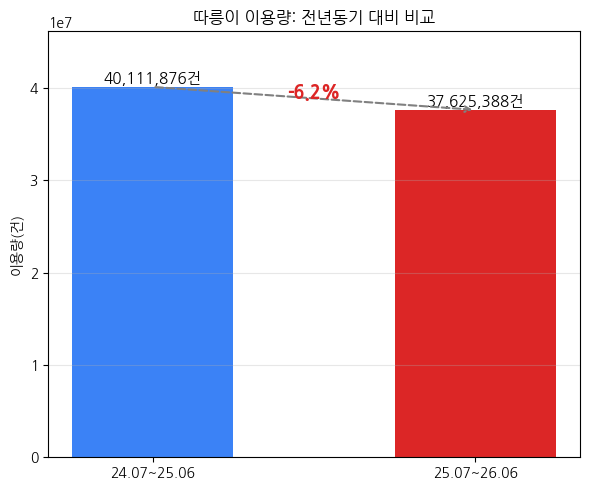

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

labels = ['24.07~25.06', '25.07~26.06']
values = [total_prev, total_curr]
bars = ax.bar(labels, values, color=['#3b82f6', '#dc2626'], width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_prev*0.01,
            f'{val:,.0f}건', ha='center', fontsize=11)

# 감소율 표시
ax.annotate('', xy=(1, total_curr), xytext=(0, total_prev),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, linestyle='--'))
ax.text(0.5, (total_prev + total_curr) / 2, f'-{decline_rate:.1f}%',
        ha='center', fontsize=13, color='#dc2626', fontweight='bold')

ax.set_ylabel('이용량(건)')
ax.set_title('따릉이 이용량: 전년동기 대비 비교')
ax.set_ylim(0, total_prev * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- 위 수치를 분석배경 표(24년7월-25년6월 이용량 / 25년7월-26년6월 이용량 / 감소율)에 그대로 채워 넣으면 됨

In [ ]:
# ── 다른 교통수단도 같은 두 구간으로 검증: "따릉이만 유일하게 감소"가 이 기간에도 성립하는지 확인 ──
prev_mask = (usage['연월'] >= '2024-07') & (usage['연월'] <= '2025-06')
curr_mask = (usage['연월'] >= '2025-07') & (usage['연월'] <= '2026-06')

for m in modes:
    prev_avg = usage.loc[prev_mask, m].mean()
    curr_avg = usage.loc[curr_mask, m].mean()
    pct = (curr_avg - prev_avg) / prev_avg * 100
    print(f'{m:6s}: 24.07~25.06 일평균 {prev_avg:,.0f}건 → 25.07~26.06 일평균 {curr_avg:,.0f}건  ({pct:+.1f}%)')

버스    : 24.07~25.06 일평균 4,605,160건 → 25.07~26.06 일평균 4,702,124건  (+2.1%)
지하철   : 24.07~25.06 일평균 5,933,927건 → 25.07~26.06 일평균 6,441,948건  (+8.6%)
택시    : 24.07~25.06 일평균 730,067건 → 25.07~26.06 일평균 728,306건  (-0.2%)
따릉이   : 24.07~25.06 일평균 106,382건 → 25.07~26.06 일평균 100,938건  (-5.1%)


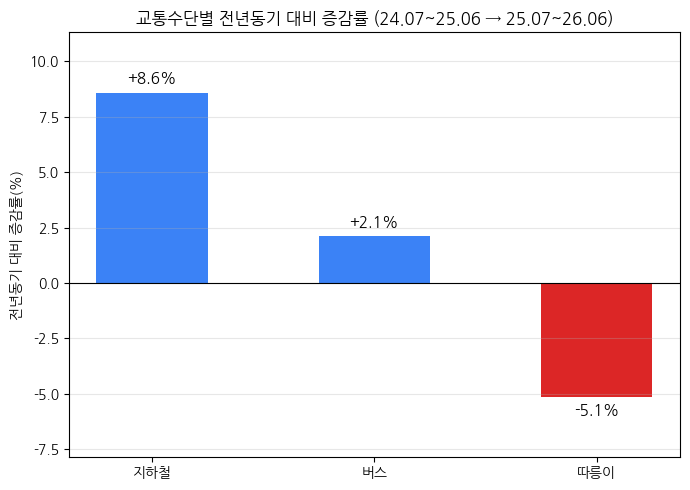

In [ ]:
mode_pct = {}
for m in modes:
    if m == '택시':   # 택시 제외
        continue
    prev_avg = usage.loc[prev_mask, m].mean()
    curr_avg = usage.loc[curr_mask, m].mean()
    mode_pct[m] = (curr_avg - prev_avg) / prev_avg * 100

# 순서 고정: 지하철, 버스, 따릉이
order = ['지하철', '버스', '따릉이']
mode_pct = {k: mode_pct[k] for k in order}

fig, ax = plt.subplots(figsize=(7, 5))
bar_colors = ['#3b82f6' if v >= 0 else '#dc2626' for v in mode_pct.values()]
bars = ax.bar(mode_pct.keys(), mode_pct.values(), color=bar_colors, width=0.5)

for bar, v in zip(bars, mode_pct.values()):
    offset = 0.3 if v >= 0 else -0.3
    va = 'bottom' if v >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, v + offset, f'{v:+.1f}%', ha='center', va=va, fontsize=11)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('전년동기 대비 증감률(%)')
ax.set_title('교통수단별 전년동기 대비 증감률 (24.07~25.06 → 25.07~26.06)')
ax.grid(axis='y', alpha=0.3)

vals = list(mode_pct.values())
margin = (max(vals) - min(vals)) * 0.2
ax.set_ylim(min(vals) - margin, max(vals) + margin)

plt.tight_layout()
plt.show()

In [ ]:
# ── 신규가입자도 동일 기간으로 재검증 ──
prev_signup = signup_usage.loc[(signup_usage['연월']>='2024-07')&(signup_usage['연월']<='2025-06'), '가입건수'].sum()
curr_signup = signup_usage.loc[(signup_usage['연월']>='2025-07')&(signup_usage['연월']<='2026-06'), '가입건수'].sum()
pct_signup = (curr_signup - prev_signup) / prev_signup * 100
print(f'신규가입자: 24.07~25.06 {prev_signup:,.0f}명 → 25.07~26.06 {curr_signup:,.0f}명 ({pct_signup:+.1f}%)')

신규가입자: 24.07~25.06 408,632명 → 25.07~26.06 373,105명 (-8.7%)


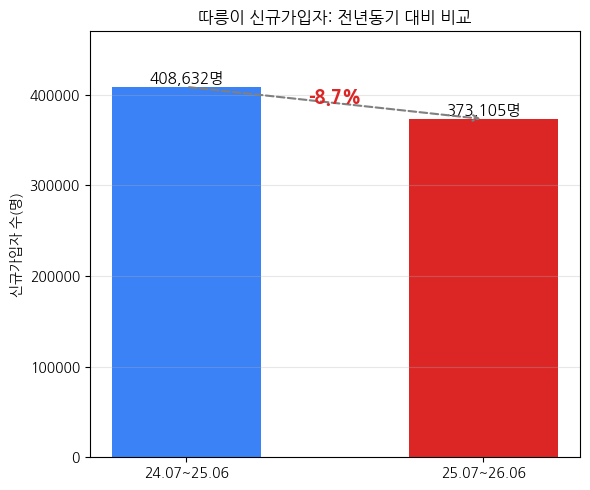

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
labels = ['24.07~25.06', '25.07~26.06']
values = [prev_signup, curr_signup]
bars = ax.bar(labels, values, color=['#3b82f6', '#dc2626'], width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + prev_signup*0.01,
            f'{val:,.0f}명', ha='center', fontsize=11)

ax.annotate('', xy=(1, curr_signup), xytext=(0, prev_signup),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, linestyle='--'))
ax.text(0.5, (prev_signup + curr_signup) / 2, f'{pct_signup:+.1f}%',
        ha='center', fontsize=13, color='#dc2626', fontweight='bold')

ax.set_ylabel('신규가입자 수(명)')
ax.set_title('따릉이 신규가입자: 전년동기 대비 비교')
ax.set_ylim(0, prev_signup * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── 전년동기 대비 월별 비교용 집계 (기간월: 7월=1 ~ 6월=12로 정렬) ──
def to_period_month(d, start_month=7):
    return (d.month - start_month) % 12 + 1

daily_prev['기간월'] = daily_prev['대여일자'].apply(to_period_month)
daily_curr['기간월'] = daily_curr['대여일자'].apply(to_period_month)

monthly_prev = daily_prev.groupby('기간월')['일별_총이용건수'].sum()
monthly_curr = daily_curr.groupby('기간월')['일별_총이용건수'].sum()
period_month_labels = ['7월','8월','9월','10월','11월','12월','1월','2월','3월','4월','5월','6월']

### 시나리오 테이블 재계산 (25.07~26.06 기준)

- 기존 다년치 테이블은 `_all`로 백업
- 아래 셀 실행 후, 시나리오1~3 차트 셀을 다시 실행하면 자동으로 새 기간이 반영됨

In [ ]:
# ── table_s1/s2/s3 재계산 (25.07~26.06 기준, 기존 다년치는 _all로 백업) ──
table_s1_all, table_s2_all, table_s3_all = table_s1, table_s2, table_s3

table_s1 = daily_curr.groupby(['연도','월','계절'], as_index=False)['일별_총이용건수'] \
    .sum().rename(columns={'일별_총이용건수': '월_총이용건수'})

table_s2 = daily_hourly_curr.groupby(['요일','평일_주말구분','대여시간'], as_index=False) \
    .agg(총이용건수=('이용건수','sum'), 평균이용건수=('이용건수','mean'))

table_s3 = daily_curr.merge(weather_daily, left_on='대여일자', right_on='날짜', how='left')

print('table_s1 (25.07~26.06):', table_s1.shape)
print('table_s2 (25.07~26.06):', table_s2.shape)
print('table_s3 (25.07~26.06):', table_s3.shape)

table_s1 (25.07~26.06): (12, 4)
table_s2 (25.07~26.06): (168, 5)
table_s3 (25.07~26.06): (365, 15)


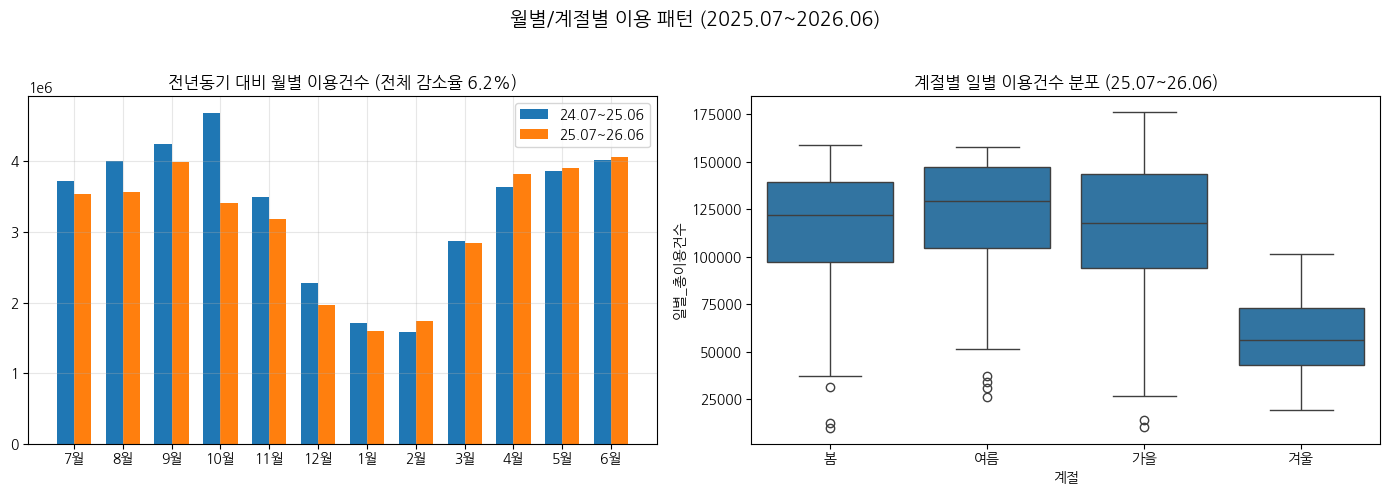

In [ ]:
# ── 시나리오1 시각화 (2025.07~2026.06, 전년동기 24.07~25.06 비교) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ① 전년동기 대비 월별 이용건수
x_bar = np.arange(1, 13)
width = 0.35
axes[0].bar(x_bar - width/2, monthly_prev.values, width, label='24.07~25.06')
axes[0].bar(x_bar + width/2, monthly_curr.values, width, label='25.07~26.06')
axes[0].set_xticks(x_bar)
axes[0].set_xticklabels(period_month_labels)
axes[0].set_title(f'전년동기 대비 월별 이용건수 (전체 감소율 {decline_rate:.1f}%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ② 계절별 분포 (일별 데이터 기준 — 계절당 표본 약 90일 확보)
season_order = ['봄', '여름', '가을', '겨울']
sns.boxplot(data=daily_curr, x='계절', y='일별_총이용건수', order=season_order, ax=axes[1])
axes[1].set_title('계절별 일별 이용건수 분포 (25.07~26.06)')

fig.suptitle('월별/계절별 이용 패턴 (2025.07~2026.06)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

- 전년동기(24.07-25.06) 대비 전체 감소(-6.2%)는 전 기간에 고르게 나타나지 않고, 7월~1월 구간에 집중되어 있음
- 특히 10월은 전년 대비 감소폭이 가장 커서(약 4.65백만건 → 3.4백만건) 가장 뚜렷한 하락을 보임
- 반면 2월, 4~6월(봄)은 오히려 전년과 비슷하거나 소폭 증가해, 최근 들어 감소세가 다소 완화되는 추세로 보임
- 계절별 분포(박스플롯)에서는 겨울이 다른 계절 대비 뚜렷하게 낮은 이용건수(중앙값 약 5.6만건)를 보이고, 봄·여름·가을은 중앙값 11~13만건 수준으로 비슷함
- 여름에는 2~4만건대의 낮은 이상치가 여러 개 관찰되는데, 장마철 강우일 이용 급감이 원인으로 추정됨(시나리오3의 강수 영향과 일치)
- 가을은 계절 내 변동폭이 가장 커서(약 2.7만~17.6만건), 날씨나 특정 요인에 따른 일별 편차가 크다는 것을 시사

## 시나리오2:평일·주말 × 시간대별 이용 패턴

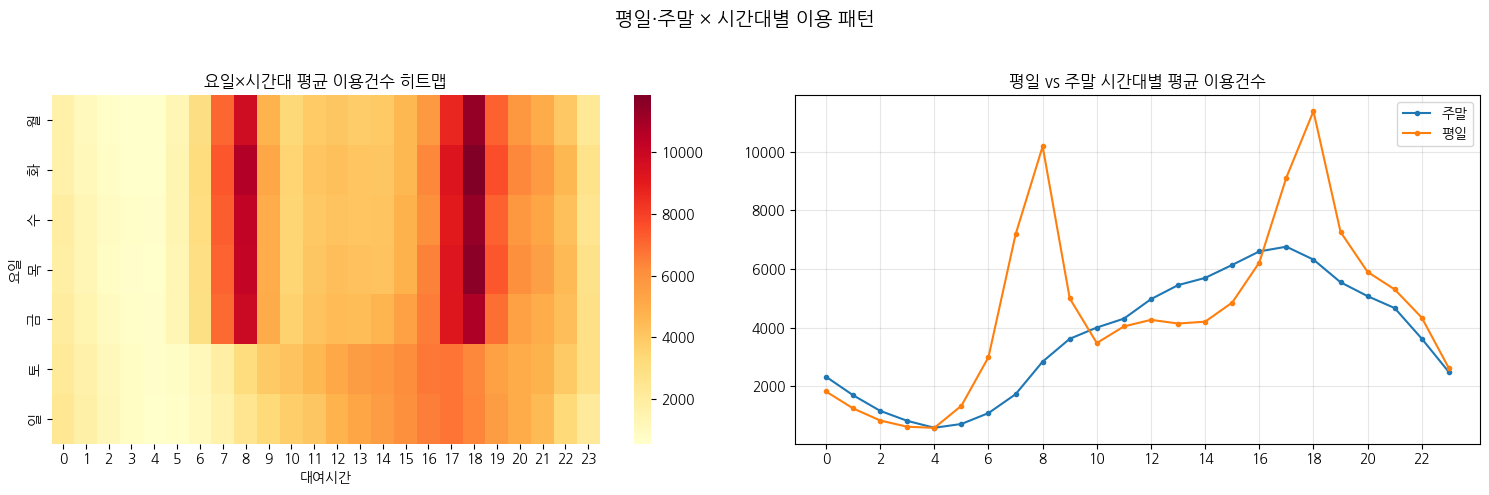

In [ ]:
day_order = ['월', '화', '수', '목', '금', '토', '일']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ① 요일×시간대 히트맵
pivot = table_s2.pivot(index='요일', columns='대여시간', values='평균이용건수').reindex(day_order)
sns.heatmap(pivot, cmap='YlOrRd', ax=axes[0])
axes[0].set_title('요일×시간대 평균 이용건수 히트맵')

# ② 평일 vs 주말 시간대별 곡선
wk = table_s2.groupby(['평일_주말구분', '대여시간'], as_index=False)['평균이용건수'].mean()
for grp, sub in wk.groupby('평일_주말구분'):
    axes[1].plot(sub['대여시간'], sub['평균이용건수'], marker='o', markersize=3, label=grp)
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_title('평일 vs 주말 시간대별 평균 이용건수')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('평일·주말 × 시간대별 이용 패턴', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

- 평일과 주말 그리고 시간대에 따른 이용 패턴을 파악하기 위해 히트맵과 라인그래프로 시각화
- 히트맵에서는 평일 오전 7-8시, 오후 17-19시까지 이용률이 집중되어 있음.
- 평일에는 출퇴근 시간에 따릉이를 이용하는 이용자가 많다고 추측됨.
- 주말에는 뚜렷하게 집중되는 패턴이 없이 오전보다는 오후가 더 많이 이용된다고 해석됨.
- 라인그래프를 보면 평일은 위에서 언급한 시간대 기울기가 가파른 반면, 주말은 전반적으로 완만한 기울기를 보임
- 따라서, 평일은 출퇴근 시간에 이용건수가 집중된 반면, 주말은 오전보다는 오후에 더 이용이 집중되어 있음을 알 수 있음.
- (참고: 25.07-26.06 1년만 봐도 다년치 때와 동일한 패턴이 나타나, 이 시간대별 패턴은 분석기간에 민감하지 않은 견고한 결과임)

## 시나리오3:날씨에 따른 이용건수 변화

기온-이용건수 상관계수: r=0.636, p=0.0000


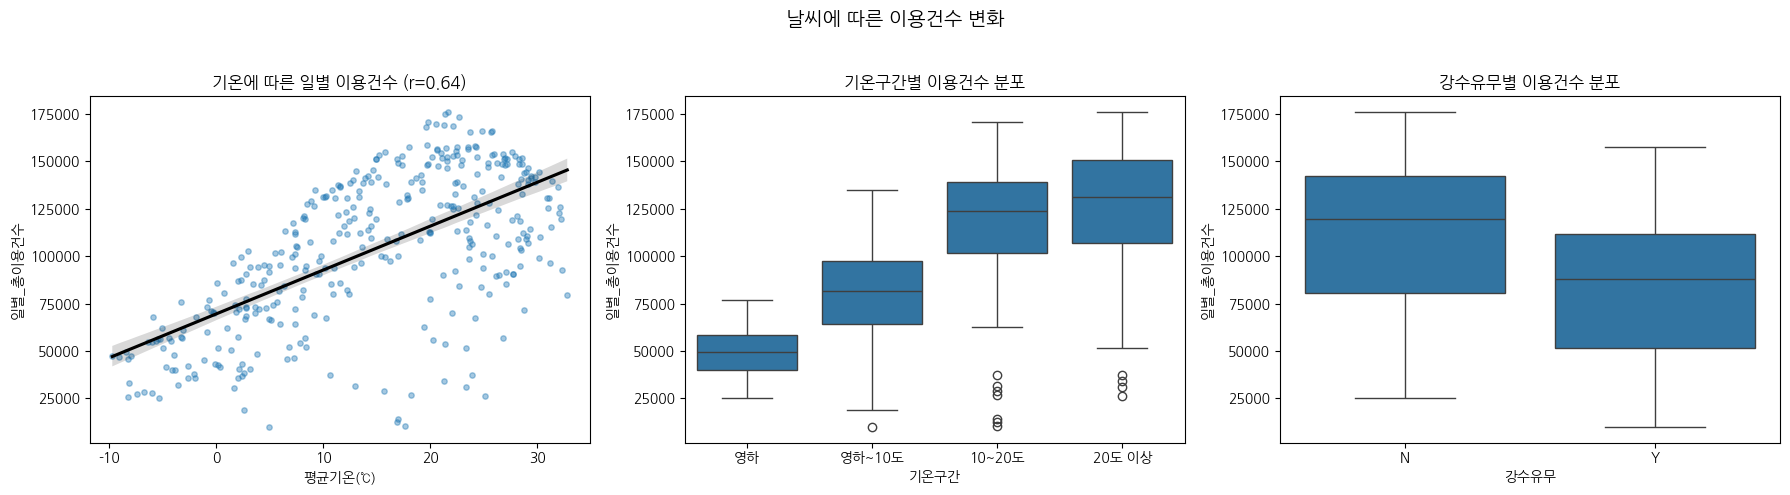

In [ ]:
from scipy import stats

# 상관계수 먼저 확인 (cell 8 스타일: 숫자 근거 → 그래프)
r, p = stats.pearsonr(table_s3['평균기온(℃)'], table_s3['일별_총이용건수'])
print(f'기온-이용건수 상관계수: r={r:.3f}, p={p:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ① 기온 vs 이용건수 산점도 + 추세선
sns.regplot(data=table_s3, x='평균기온(℃)', y='일별_총이용건수',
            scatter_kws={'alpha':0.4, 's':15}, line_kws={'color':'black'}, ax=axes[0])
axes[0].set_title(f'기온에 따른 일별 이용건수 (r={r:.2f})')

# ② 기온구간별 분포
axes[1].sharey = False
sns.boxplot(data=table_s3, x='기온구간', y='일별_총이용건수',
            order=['영하','영하~10도','10~20도','20도 이상'], ax=axes[1])
axes[1].set_title('기온구간별 이용건수 분포')

# ③ 강수유무별 비교
sns.boxplot(data=table_s3, x='강수유무', y='일별_총이용건수', order=['N','Y'], ax=axes[2])
axes[2].set_title('강수유무별 이용건수 분포')

fig.suptitle('날씨에 따른 이용건수 변화', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

- 날씨에 대한 이용 패턴을 파악하기 위해서 기온, 강수량 데이터를 이용해서 분석
- 강수현상에는 비, 이슬비, 얼음싸라기, 눈, 싸락눈, 진눈깨비, 싸락우박, 우박, 눈보라 등이 포함
- 기온에 따른 이용패턴의 상관관계를 확인하기 위해서 산점도로 시각화 진행
- 확인결과, 뚜렷한 양의 상관관계를 가지는 것을 확인.
- 다만 20도 이상 구간에서는 증가세가 둔화되고 저조한 이상치도 관찰됨
- 상자그림을 통해서 기온별 분포를 확인해본 결과 온도가 낮을수록 이용건수 역시 낮은 분포를 보임
- 강수유무로 이용건수의 분포를 확인하기 위해 상자그림으로 시각화
- 강수유무별 이용건수 분포를 비교하면 강수량이 없을 때 이용건수가 높은 분포를 보임
- 따라서, 따릉이는 기온이 높을수록, 강수량이 낮을수록 이용량이 늘어남을 확인.

In [ ]:
recent = usage[(usage['연월'] >= '2025-07') & (usage['연월'] <= '2026-06')].reset_index(drop=True)
assert len(recent) == 12, f'12개월이 아님: {len(recent)}개월'

x_recent = np.arange(len(recent))
print('[최근 1년: 2025.07~2026.06]')
for m in modes:
    y = recent[m].values
    slope, intercept = np.polyfit(x_recent, y, 1)
    print(f'{m:6s}: 기울기 = {slope:+,.0f}건/월  (전체기간 기울기와 비교: cell8 결과 참고)')

[최근 1년: 2025.07~2026.06]
버스    : 기울기 = +10,270건/월  (전체기간 기울기와 비교: cell8 결과 참고)
지하철   : 기울기 = +36,132건/월  (전체기간 기울기와 비교: cell8 결과 참고)
택시    : 기울기 = -1,101건/월  (전체기간 기울기와 비교: cell8 결과 참고)
따릉이   : 기울기 = +213건/월  (전체기간 기울기와 비교: cell8 결과 참고)


# 공간에 따른 따릉이 이용패턴 분석

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
%pip install koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
# macOS 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'

In [4]:
H225_df = pd.read_csv('서울특별시 공공자전거 대여소별 이용정보(월별)_25.7-12.csv')
H126_df = pd.read_csv('서울특별시 공공자전거 대여소별 이용정보(월별)_26.1-6.csv')

In [5]:
merged_df = pd.concat([H225_df, H126_df], ignore_index=True)

In [6]:
# 각 컬럼별 결측치 총 개수 확인
print(merged_df.isnull().sum())

# 결측치가 하나라도 포함된 전체 행 확인
merged_df[merged_df.isnull().any(axis=1)]

자치구     0
대여소명    0
기준년월    0
대여건수    0
반납건수    0
dtype: int64


,자치구,대여소명,기준년월,대여건수,반납건수


In [7]:
# 완전히 동일한 중복 행의 개수 확인
print(merged_df.duplicated().sum())

# 중복된 데이터(행) 직접 조회 (원본과 중복본 모두 표시)
merged_df[merged_df.duplicated(keep=False)]

0


,자치구,대여소명,기준년월,대여건수,반납건수


In [8]:
merged_df.describe()

,기준년월,대여건수,반납건수
count,33192.000000,33192.000000,33192.000000
mean,202556.582008,1133.606170,1127.569203
std,47.028198,1119.738384,1163.437970
min,202507.000000,0.000000,0.000000
25%,202510.000000,410.000000,361.000000
50%,202601.000000,805.000000,790.000000
75%,202604.000000,1471.000000,1490.000000
max,202606.000000,18426.000000,18654.000000


In [9]:
Q1_1 = merged_df['대여건수'].quantile(0.25)
Q3_1 = merged_df['대여건수'].quantile(0.75)
IQR_1 = Q3_1 - Q1_1

outliers_merged_rent = merged_df[(merged_df['대여건수'] < (Q1_1 - 1.5 * IQR_1)) | (merged_df['대여건수'] > (Q3_1 + 1.5 * IQR_1))]

In [10]:
print(outliers_merged_rent)

       자치구               대여소명    기준년월  대여건수  반납건수
2      양천구  731. 서울시 도로환경관리센터  202507  3135  3218
13     양천구    744. 신목동역 2번 출구  202507  3712  3676
15     양천구      746. 목동2단지 상가  202507  3636  3611
35     강동구      1024.  강동구청 앞  202507  3490  3540
39     강동구        1029. 성내어울터  202507  3287  3250
...    ...                ...     ...   ...   ...
32934  종로구    3410.종로3가역 8번출구  202606  3122  3153
32937  종로구        3413.종로플레이스  202606  3183  3161
32968  종로구   361. 동묘앞역 1번출구 뒤  202606  3309  3546
33038   중구       431. 청계천 영도교  202606  4238  4113
33090   중구     6058. 시청역 2번출구  202606  3664  3518

[1940 rows x 5 columns]


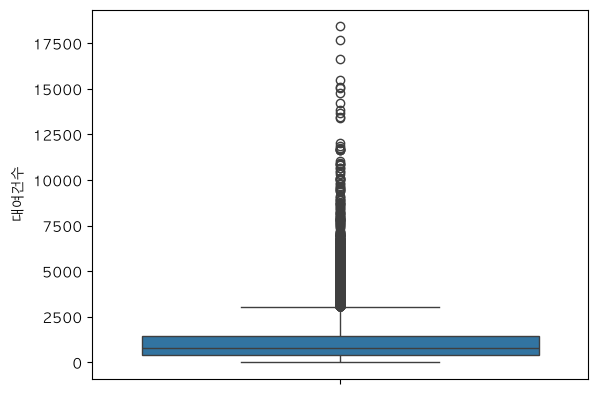

In [11]:
sns.boxplot(y=merged_df['대여건수'])
plt.show()

In [12]:
df_station = pd.read_excel('공공자전거 대여소 정보(26.6월 기준).xlsx', skiprows=5, header=None)

df_station.columns = [
    '대여소번호', '대여소명', '자치구', '상세주소', 
    '위도', '경도', '설치시기', 'LCD거치대수', 'QR거치대수', '운영방식'
]

In [13]:
merged_df.dtypes

자치구       str
대여소명      str
기준년월    int64
대여건수    int64
반납건수    int64
dtype: object

In [14]:
df_station.dtypes

대여소번호        int64
대여소명           str
자치구            str
상세주소           str
위도         float64
경도         float64
설치시기        object
LCD거치대수    float64
QR거치대수     float64
운영방식           str
dtype: object

In [15]:
split_merged_df = merged_df['대여소명'].str.split('.',n=1, expand=True)
merged_df['대여소번호'] = split_merged_df[0].str.strip() 
merged_df['대여소이름'] = split_merged_df[1].str.strip()

In [16]:
merged_df.head()

,자치구,대여소명,기준년월,대여건수,반납건수,대여소번호,대여소이름
0,마포구,108. 서교동 사거리,202507,1277,1314,108,서교동 사거리
1,양천구,729. 서부식자재마트 건너편,202507,1658,1808,729,서부식자재마트 건너편
2,양천구,731. 서울시 도로환경관리센터,202507,3135,3218,731,서울시 도로환경관리센터
3,양천구,733. 신정이펜하우스314동,202507,876,375,733,신정이펜하우스314동
4,양천구,734. 신트리공원 입구,202507,2987,2958,734,신트리공원 입구


In [17]:
# 1. 문자는 NaN으로 변환 (기본적으로 float 타입이 됨)
merged_df['대여소번호'] = pd.to_numeric(merged_df['대여소번호'], errors='coerce')

# 2. NaN을 유지한 채 정수형으로 변환 ('Int64' 사용)
merged_df['대여소번호'] = merged_df['대여소번호'].astype('Int64')

In [18]:
df_station['대여소번호'] = df_station['대여소번호'].astype('Int64')

In [19]:
df_station['LCD거치대수'] = df_station['LCD거치대수'].fillna(0)
df_station['QR거치대수'] = df_station['QR거치대수'].fillna(0)

df_station['총거치대수'] = df_station['LCD거치대수'] + df_station['QR거치대수']
df_station.head()

,대여소번호,대여소명,자치구,상세주소,위도,경도,설치시기,LCD거치대수,QR거치대수,운영방식,총거치대수
0,102,망원역 1번출구 앞,마포구,서울특별시 마포구 월드컵로 72,37.555649,126.910629,2015-09-06 23:42:06,0.0,15.0,QR,15.0
1,103,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,0.0,14.0,QR,14.0
2,104,합정역 1번출구 앞,마포구,서울특별시 마포구 양화로 59,37.550629,126.914986,2015-09-06 23:44:31,0.0,13.0,QR,13.0
3,105,합정역 5번출구 앞,마포구,서울특별시 마포구 양화로 48,37.550007,126.914825,2015-09-06 23:45:30,0.0,5.0,QR,5.0
4,106,합정역 7번출구 앞,마포구,서울특별시 마포구 독막로 4,37.548645,126.912827,2015-09-06 23:46:31,0.0,12.0,QR,12.0


In [20]:
station_info = df_station[['대여소번호', '상세주소', '위도', '경도', 'LCD거치대수', 'QR거치대수', '총거치대수', '운영방식']]

In [21]:
merged_df_2 = pd.merge(merged_df, station_info, on='대여소번호', how='left')

In [22]:
merged_df_2.head()

,자치구,대여소명,기준년월,대여건수,반납건수,대여소번호,대여소이름,상세주소,위도,경도,LCD거치대수,QR거치대수,총거치대수,운영방식
0,마포구,108. 서교동 사거리,202507,1277,1314,108,서교동 사거리,서울특별시 마포구 양화로 93,37.552746,126.918617,0.0,10.0,10.0,QR
1,양천구,729. 서부식자재마트 건너편,202507,1658,1808,729,서부식자재마트 건너편,서울특별시 양천구 신정동 236,37.510380,126.866798,10.0,0.0,10.0,LCD
2,양천구,731. 서울시 도로환경관리센터,202507,3135,3218,731,서울시 도로환경관리센터,서울특별시 양천구 목동동로 316-6,37.529900,126.876541,10.0,0.0,10.0,LCD
3,양천구,733. 신정이펜하우스314동,202507,876,375,733,신정이펜하우스314동,서울특별시 양천구 신정이펜1로50,37.514099,126.831001,10.0,0.0,10.0,LCD
4,양천구,734. 신트리공원 입구,202507,2987,2958,734,신트리공원 입구,서울특별시 양천구 신정동 310-8,37.513950,126.856056,10.0,0.0,10.0,LCD


In [23]:
# 1. 자치구별 그룹화 및 집계 (대여건수, 반납건수 합산)
gu_grouped = merged_df_2.groupby('자치구')[['대여건수', '반납건수']].sum().reset_index()

# 2. 총 이용건수(대여+반납) 컬럼 생성 및 내림차순 정렬
gu_grouped['총이용건수'] = gu_grouped['대여건수'] + gu_grouped['반납건수']
gu_grouped['순수요'] = gu_grouped['대여건수'] - gu_grouped['반납건수']
gu_grouped = gu_grouped.sort_values(by='총이용건수', ascending=False)

gu_grouped.head()

,자치구,대여건수,반납건수,총이용건수,순수요
3,강서구,4688929,4671100,9360029,17829
17,송파구,3528501,3517372,7045873,11129
19,영등포구,3508117,3453650,6961767,54467
18,양천구,2360733,2376220,4736953,-15487
8,노원구,2203338,2201762,4405100,1576


In [24]:
gu_coords = {
    '강남구': (37.5173, 127.0473), '강동구': (37.5301, 127.1238),
    '강북구': (37.6396, 127.0257), '강서구': (37.5509, 126.8495),
    '관악구': (37.4784, 126.9516), '광진구': (37.5385, 127.0824),
    '구로구': (37.4954, 126.8874), '금천구': (37.4568, 126.8955),
    '노원구': (37.6542, 127.0568), '도봉구': (37.6688, 127.0471),
    '동대문구': (37.5744, 127.0398), '동작구': (37.5124, 126.9393),
    '마포구': (37.5663, 126.9016), '서대문구': (37.5791, 126.9368),
    '서초구': (37.4837, 127.0324), '성동구': (37.5634, 127.0369),
    '성북구': (37.5891, 127.0182), '송파구': (37.5145, 127.1059),
    '양천구': (37.5170, 126.8665), '영등포구': (37.5264, 126.8962),
    '용산구': (37.5326, 126.9900), '은평구': (37.6027, 126.9291),
    '종로구': (37.5730, 126.9794), '중구': (37.5641, 126.9979),
    '중랑구': (37.6066, 127.0927)
}

# 기존 구별 집계 데이터프레임에 위경도 매핑
gu_grouped['위도'] = gu_grouped['자치구'].map(lambda x: gu_coords.get(x, (None, None))[0])
gu_grouped['경도'] = gu_grouped['자치구'].map(lambda x: gu_coords.get(x, (None, None))[1])

In [25]:
gu_grouped.head()

,자치구,대여건수,반납건수,총이용건수,순수요,위도,경도
3,강서구,4688929,4671100,9360029,17829,37.5509,126.8495
17,송파구,3528501,3517372,7045873,11129,37.5145,127.1059
19,영등포구,3508117,3453650,6961767,54467,37.5264,126.8962
18,양천구,2360733,2376220,4736953,-15487,37.5170,126.8665
8,노원구,2203338,2201762,4405100,1576,37.6542,127.0568


In [26]:
gu_grouped = gu_grouped.sort_values(by='총이용건수', ascending=False).reset_index(drop=True)
fig_total = px.bar(gu_grouped, x='자치구', y='총이용건수', color='총이용건수', color_continuous_scale='RdBu', title='최근 1년 서울시 자치구별 따릉이 총이용건수', text_auto='.2s', width=800, height=500)
fig_total.show()

In [27]:
gu_grouped = gu_grouped.sort_values(by='대여건수', ascending=False).reset_index(drop=True)
fig_borrow = px.bar(gu_grouped, x='자치구', y='대여건수', color='대여건수', color_continuous_scale='RdBu', title='최근 1년 서울시 자치구별 따릉이 대여건수', text_auto='.2s', width=800, height=500)
fig_borrow.show()

In [28]:
fig_return = px.bar(gu_grouped, x='자치구', y='반납건수', color='반납건수', color_continuous_scale='RdBu', title='최근 1년 서울시 자치구별 따릉이 반납건수', text_auto='.2s', width=800, height=500)
fig_return.show()

In [29]:
gu_grouped = gu_grouped.sort_values(by='순수요', ascending=False)
fig_net = px.bar(gu_grouped, x='자치구', y='순수요', color='순수요',
                        title='최근 1년 서울시 자치구별 따릉이 순수요(=대여-반납)',
                        text_auto='.2s',
                        color_continuous_scale='RdBu',
                        color_continuous_midpoint=0,
                        width=800, height=500)
fig_net.show()

In [30]:
gu_grouped['불균형규모'] = gu_grouped['순수요'].abs()

# 1. 0 부근이 지도에 묻히지 않도록 흰색 대신 선명한 노란색(#ffff33) 배치
custom_scale = [
    [0.0, '#b2182b'],   # 음수 최댓값: 짙은 빨강
    [0.45, '#ef8a62'],  # 음수 중간값: 연한 빨강
    [0.5, '#ffff33'],   # 0 부근: 눈에 잘 띄는 노란색 (배경 묻힘 방지)
    [0.55, '#67a9cf'],  # 양수 중간값: 연한 파랑
    [1.0, '#2166ac']    # 양수 최댓값: 짙은 파랑
]

# 2. 순수요가 0에 가까운 구도 점처럼 사라지지 않도록 최소 기본 크기(+3000) 보정
gu_grouped['표시크기'] = gu_grouped['불균형규모'] + 3000

# 3. 지도 생성
fig_gu_map = px.scatter_mapbox(
    gu_grouped,
    lat='위도',
    lon='경도',
    color='순수요',
    color_continuous_scale=custom_scale,
    color_continuous_midpoint=0,
    range_color=[-15000, 15000],          # 색상 포화 범위를 좁혀 색을 더 진하게 표현
    size='표시크기',
    size_max=30,
    hover_name='자치구',
    hover_data={'순수요': True, '표시크기': False, '위도': False, '경도': False},
    zoom=10.5,
    center={"lat": 37.5665, "lon": 126.9780},
    mapbox_style='open-street-map',
    width=800, height=600
)

# 4. line 제거 후 불투명도만 100% 적용
fig_gu_map.update_traces(marker=dict(opacity=1.0))

fig_gu_map.update_layout(
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
    title="최근 1년 서울시 자치구별 따릉이 순수요(=대여-반납) 지도"
)

fig_gu_map.show()

/var/folders/fb/j0dj2sw131zfwpcnfm5zhqlm0000gn/T/ipykernel_42415/2489484738.py:16: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_gu_map = px.scatter_mapbox(


In [31]:
# 1. 대여소별 이용건수 집계 (지도 시각화를 위해 상세주소, 위경도 포함)
station_grouped = merged_df_2.groupby(['대여소번호', '상세주소', '위도', '경도','자치구'])[['대여건수', '반납건수']].sum().reset_index()
station_grouped['총이용건수'] = station_grouped['대여건수'] + station_grouped['반납건수']

In [32]:
# 2. 상/하위 10% 기준값(Threshold) 계산
# 0.90은 상위 10%, 0.10은 하위 10%를 의미합니다.
top10_val = station_grouped['총이용건수'].quantile(0.90)
bottom10_val = station_grouped['총이용건수'].quantile(0.10)

# 3. 조건에 맞는 대여소 데이터프레임 분리
top10_df = station_grouped[station_grouped['총이용건수'] >= top10_val]
bottom10_df = station_grouped[station_grouped['총이용건수'] <= bottom10_val]

In [33]:
# 4. 상위 10% 대여소 지도 시각화 (입지 특징 파악용)
fig_top10 = px.scatter_map(
    top10_df, 
    lat='위도', 
    lon='경도', 
    hover_name='대여소번호', 
    hover_data=['상세주소', '총이용건수'],
    color_discrete_sequence=['blue'], 
    zoom=10, 
    title='최근 1년 이용량 상위 10% 대여소 위치 파악',
    width = 1000,
    height = 800
)
fig_top10.update_layout(map_style='open-street-map')
fig_top10.show()

In [34]:
fig_bottom10 = px.scatter_map(
    bottom10_df, 
    lat='위도', 
    lon='경도', 
    hover_name='대여소번호', 
    hover_data=['상세주소', '총이용건수'],
    color_discrete_sequence=['red'], 
    zoom=10, 
    title='최근 1년 이용량 하위 10% 대여소 위치 파악',
    width = 1000,
    height = 800
)

fig_bottom10.update_layout(map_style="open-street-map")
fig_bottom10.show()

In [58]:
# 1. 대여소별로 대여건수와 반납건수 합산
od_df = merged_df_2.groupby(['대여소번호', '상세주소', '위도', '경도', '자치구'])[['대여건수', '반납건수']].sum().reset_index()

# 2. 순수요(Net Demand) 계산: 대여건수 - 반납건수
# 양수(+): 대여가 더 많음 (자전거가 부족해지는 경향이 있는 대여소)
# 음수(-): 반납이 더 많음 (자전거가 과도하게 쌓이는 경향이 있는 대여소)
od_df['순수요'] = od_df['대여건수'] - od_df['반납건수']
top10_od_val = od_df['순수요'].quantile(0.90)
btm10_od_val = od_df['순수요'].quantile(0.10)

# 3. 불균형이 가장 심한 대여소 확인
top10_bs = od_df[od_df['순수요']>=top10_od_val].sort_values(by='순수요', ascending=False)
top10_rs = od_df[od_df['순수요']<=btm10_od_val].sort_values(by='순수요', ascending=True)

In [59]:
od_df.head()

,대여소번호,상세주소,위도,경도,자치구,대여건수,반납건수,순수요
0,102,서울특별시 마포구 월드컵로 72,37.555649,126.910629,마포구,34065,35842,-1777
1,103,서울특별시 마포구 월드컵로 79,37.554951,126.910835,마포구,25434,28710,-3276
2,104,서울특별시 마포구 양화로 59,37.550629,126.914986,마포구,15610,13094,2516
3,105,서울특별시 마포구 양화로 48,37.550007,126.914825,마포구,8894,7193,1701
4,106,서울특별시 마포구 독막로 4,37.548645,126.912827,마포구,23165,22800,365


In [60]:
top10_bs

,대여소번호,상세주소,위도,경도,자치구,대여건수,반납건수,순수요
1828,3513,서울특별시 성동구 하왕십리동 860-1 상왕십리역 1번출구,37.564610,127.029198,성동구,24315,13729,10586
457,711,서울특별시 양천구 신월동 1063-4,37.517059,126.848488,양천구,12746,3258,9488
373,574,서울특별시 광진구 능동로 216 아차산역4번출구,37.551849,127.088982,광진구,24905,15422,9483
2394,4591,영등포구 가마산로79길19\n(신길자이@ 104동 쪽),37.506012,126.915886,영등포구,10881,1721,9160
1234,1924,서울특별시 구로구 남부순환로 1299,37.478741,126.895096,구로구,15466,6560,8906
...,...,...,...,...,...,...,...,...
1655,2655,송파동 169,37.500580,127.118843,송파구,9122,7233,1889
1838,3529,서울특별시 광진구 능동로 216 어린이대공원정문,37.549789,127.075928,광진구,9616,7734,1882
2300,4454,거여동 274,37.486877,127.152695,송파구,2967,1098,1869
1143,1734,서울특별시 도봉구 해등로 218 쌍문현대1차아파트 108동 앞,37.658150,127.032669,도봉구,8854,6987,1867


In [61]:
top10_rs

,대여소번호,상세주소,위도,경도,자치구,대여건수,반납건수,순수요
650,996,서울특별시 은평구 연서로 9 센타폴리스,37.599968,126.915726,은평구,37297,53472,-16175
8,113,서울특별시 마포구 양화로 165,37.557438,126.923821,마포구,54287,67535,-13248
2133,4096,창동 324-1,37.652836,127.045502,도봉구,27513,37590,-10077
2604,4964,암사동 400-3,37.557289,127.138954,강동구,17768,27202,-9434
1674,2717,강서구 마곡중앙8로 71,37.561337,126.833900,강서구,51660,61082,-9422
...,...,...,...,...,...,...,...,...
948,1408,서울특별시 중랑구 동일로 지하 901 먹골역 6번출구 앞,37.610722,127.077477,중랑구,11116,12680,-1564
2438,4659,서울특별시 은평구 응암로291,37.597504,126.919998,은평구,10895,12450,-1555
1252,1958,서울특별시 구로구 가마산로 272,37.495781,126.890121,구로구,17990,19544,-1554
935,1390,서울특별시 성북구 석관동 323-2,37.606461,127.061623,성북구,15161,16704,-1543


In [62]:
fig_top10_bs = px.scatter_map(
    top10_bs, 
    lat='위도', 
    lon='경도', 
    hover_name='대여소번호', 
    hover_data=['상세주소', '순수요'],
    color_discrete_sequence=['red'], 
    zoom=10, 
    title='최근 1년 순대여(대여>반납) 상위 10% 대여소 위치 파악',
    width = 1000,
    height = 800
)

fig_top10_bs.update_layout(map_style="open-street-map")
fig_top10_bs.show()

In [63]:
fig_top10_rs = px.scatter_map(
    top10_rs, 
    lat='위도', 
    lon='경도', 
    hover_name='대여소번호', 
    hover_data=['상세주소', '순수요'],
    color_discrete_sequence=['blue'], 
    zoom=10, 
    title='최근 1년 순반납(대여<반납) 상위 10% 대여소 위치 파악',
    width = 1000,
    height = 800
)

fig_top10_rs.update_layout(map_style="open-street-map")
fig_top10_rs.show()

In [41]:
df_station.head()

,대여소번호,대여소명,자치구,상세주소,위도,경도,설치시기,LCD거치대수,QR거치대수,운영방식,총거치대수
0,102,망원역 1번출구 앞,마포구,서울특별시 마포구 월드컵로 72,37.555649,126.910629,2015-09-06 23:42:06,0.0,15.0,QR,15.0
1,103,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,0.0,14.0,QR,14.0
2,104,합정역 1번출구 앞,마포구,서울특별시 마포구 양화로 59,37.550629,126.914986,2015-09-06 23:44:31,0.0,13.0,QR,13.0
3,105,합정역 5번출구 앞,마포구,서울특별시 마포구 양화로 48,37.550007,126.914825,2015-09-06 23:45:30,0.0,5.0,QR,5.0
4,106,합정역 7번출구 앞,마포구,서울특별시 마포구 독막로 4,37.548645,126.912827,2015-09-06 23:46:31,0.0,12.0,QR,12.0


In [42]:
merged_df_2.head()

,자치구,대여소명,기준년월,대여건수,반납건수,대여소번호,대여소이름,상세주소,위도,경도,LCD거치대수,QR거치대수,총거치대수,운영방식
0,마포구,108. 서교동 사거리,202507,1277,1314,108,서교동 사거리,서울특별시 마포구 양화로 93,37.552746,126.918617,0.0,10.0,10.0,QR
1,양천구,729. 서부식자재마트 건너편,202507,1658,1808,729,서부식자재마트 건너편,서울특별시 양천구 신정동 236,37.510380,126.866798,10.0,0.0,10.0,LCD
2,양천구,731. 서울시 도로환경관리센터,202507,3135,3218,731,서울시 도로환경관리센터,서울특별시 양천구 목동동로 316-6,37.529900,126.876541,10.0,0.0,10.0,LCD
3,양천구,733. 신정이펜하우스314동,202507,876,375,733,신정이펜하우스314동,서울특별시 양천구 신정이펜1로50,37.514099,126.831001,10.0,0.0,10.0,LCD
4,양천구,734. 신트리공원 입구,202507,2987,2958,734,신트리공원 입구,서울특별시 양천구 신정동 310-8,37.513950,126.856056,10.0,0.0,10.0,LCD


In [43]:
def aggregate_station_data(df, days, rack_col='총거치대수'):
    # 1. 대여소번호 기준 기본 정보 및 건수 합산 집계
    summary_df = df.groupby('대여소번호', as_index=False).agg({
        '자치구': 'first',
        '대여소명': 'first',
        '대여소이름': 'first',
        '상세주소': 'first',
        '위도': 'first',
        '경도': 'first',
        '총거치대수': 'first',
        '대여건수': 'sum',
        '반납건수': 'sum'
    })
    
    # 2. 총 이용건수 계산 (대여건수 + 반납건수)
    summary_df['총이용건수'] = summary_df['대여건수'] + summary_df['반납건수']
    
    # 3. 일평균 회전율 계산: 총 대여건수 / (거치대수 * 운영일수)
    summary_df['일평균회전율'] = summary_df['대여건수'] / (summary_df[rack_col] * days)
    
    # (선택) 회전율 소수점 둘째 자리 반올림
    summary_df['일평균회전율'] = summary_df['일평균회전율'].round(2)
    
    return summary_df

summary_df = aggregate_station_data(merged_df_2, days=184, rack_col='총거치대수')

# 결과 확인
summary_df.head()

,대여소번호,자치구,대여소명,대여소이름,상세주소,위도,경도,총거치대수,대여건수,반납건수,총이용건수,일평균회전율
0,102,마포구,102. 망원역 1번출구 앞,망원역 1번출구 앞,서울특별시 마포구 월드컵로 72,37.555649,126.910629,15.0,34065,35842,69907,12.34
1,103,마포구,103. 망원역 2번출구 앞,망원역 2번출구 앞,서울특별시 마포구 월드컵로 79,37.554951,126.910835,14.0,25434,28710,54144,9.87
2,104,마포구,104. 합정역 1번출구 앞,합정역 1번출구 앞,서울특별시 마포구 양화로 59,37.550629,126.914986,13.0,15610,13094,28704,6.53
3,105,마포구,105. 합정역 5번출구 앞,합정역 5번출구 앞,서울특별시 마포구 양화로 48,37.550007,126.914825,5.0,8894,7193,16087,9.67
4,106,마포구,106. 합정역 7번출구 앞,합정역 7번출구 앞,서울특별시 마포구 독막로 4,37.548645,126.912827,12.0,23165,22800,45965,10.49


In [44]:
mean_rack = summary_df['총거치대수'].mean()
mean_turnover = summary_df['일평균회전율'].mean()

In [45]:
print(f"거치대 평균개수 : {mean_rack:.2f}개")
print(f"거치대당 일평균회전율 : {mean_turnover:.2f}개")

거치대 평균개수 : 12.06개
거치대당 일평균회전율 : 6.41개


In [46]:
fig_quadrant = px.scatter(
    summary_df,
    x='총거치대수',
    y='일평균회전율',
    hover_name='대여소번호',
    hover_data= ['상세주소', '총이용건수'],
    title='최근 1년 따릉이대여소 인프라 효율성 사분면 분석',
    width = 1000,
    height = 900
)

fig_quadrant.add_hline(y=mean_turnover, line_color='gray', annotation_text='평균회전율')
fig_quadrant.add_vline(x=mean_rack, line_color='gray', annotation_text='평균거치대수')

fig_quadrant.add_annotation(x=summary_df['총거치대수'].max() * 0.8, y=summary_df['일평균회전율'].max() * 0.9,
            text="[제1사분면] 핵심 거점 대여소 (규모 큼, 회전율 높음)",
            showarrow=False, font=dict(size=12, color="green"))

fig_quadrant.add_annotation(x=summary_df['총거치대수'].min() * 0.2, y=summary_df['일평균회전율'].max() * 0.9,
            text="[제2사분면] 과수요 대여소 (규모 작음, 회전율 높음)",
            showarrow=False, font=dict(size=12, color="red"))

fig_quadrant.add_annotation(x=summary_df['총거치대수'].max() * 0.8, y=summary_df['일평균회전율'].min() * 0.1,
            text="[제4사분면] 과공급 대여소 (규모 큼, 회전율 낮음)",
            showarrow=False, font=dict(size=12, color="blue"))

fig_quadrant.show()

In [47]:
# 원하는 사분면 조건에 맞춰 필터링하기
q2_df = summary_df[
    (summary_df['총거치대수'] < mean_rack) & 
    (summary_df['일평균회전율'] > mean_turnover)
]

print(f"=== 최근 1년 과수요 대여소 (규모 작음, 회전율 높음) (총 {len(q2_df)}개소) ===")
q2_df[['대여소번호', '상세주소', '총거치대수', '일평균회전율']].sort_values(by='일평균회전율', ascending=False).head(10)

=== 최근 1년 과수요 대여소 (규모 작음, 회전율 높음) (총 743개소) ===


,대여소번호,상세주소,총거치대수,일평균회전율
749,1124,서울특별시 강서구 공항대로 280,6.0,59.59
1636,2608,송파구 올림픽로 326,10.0,39.00
2572,4865,송파구 방이동 45-4,5.0,38.14
2046,3882,서울특별시 광진구 자양로3가길 28,3.0,37.94
343,529,서울특별시 성동구 용답동 224-3 장안평역 8번 출구 앞,8.0,37.33
1958,3680,강동구 성내동 192-8,6.0,35.52
1856,3518,서울특별시 광진구 천호대로 지하 550 군자역 7번출구 뒤,8.0,34.13
2663,5082,화곡로 416,9.0,33.79
1867,3533,서울특별시 광진구 능동로 92 건대입구역 사거리(롯데백화점),10.0,33.66
1896,3575,서울특별시 광진구 아차산로 360 서원빌딩,6.0,33.55


In [48]:
# 원하는 사분면 조건에 맞춰 필터링하기
q4_df = summary_df[
    (summary_df['총거치대수'] > mean_rack) & 
    (summary_df['일평균회전율'] < mean_turnover)
]

print(f"=== 최근 1년 과공급 대여소 (규모 큼, 회전율 낮음) (총 {len(q2_df)}개소) ===")
q4_df[['대여소번호', '상세주소', '총거치대수', '일평균회전율']].sort_values(by='일평균회전율', ascending=True).head(10)

=== 최근 1년 과공급 대여소 (규모 큼, 회전율 낮음) (총 743개소) ===


,대여소번호,상세주소,총거치대수,일평균회전율
1216,1845,서울특별시 금천구 벚꽃로40,15.0,0.0
87,211,서울특별시 영등포구 국회대로68길 7,13.0,0.0
1502,2322,서울특별시 강남구 테헤란로 534,15.0,0.0
1367,2113,서울특별시 관악구 신사로 7,20.0,0.0
503,764,양천구 목동동로 323,30.0,0.0
1530,2355,서울특별시 강남구 봉은사로 524,20.0,0.0
681,1026,서울특별시 명일동 59,14.0,0.0
2757,5854,여의대로 70,26.0,0.0
2758,5855,여의대로 66,31.0,0.0
690,1035,서울특별시 명일동 46-5,25.0,0.0


In [49]:
top20_val_to = q2_df['일평균회전율'].quantile(0.80)
btm20_val_to = q4_df['일평균회전율'].quantile(0.20)

# 3. 불균형이 가장 심한 대여소 확인
top20_q2_to = q2_df[q2_df['일평균회전율']>=top20_val_to].sort_values(by='일평균회전율', ascending=False)
btm20_q4_to = q4_df[q4_df['일평균회전율']<=btm20_val_to].sort_values(by='일평균회전율', ascending=True)

In [50]:
# 1. 메인 산점도 생성 (기존 옵션 유지 + opacity 적용)
fig_q2 = px.scatter_mapbox(
    top20_q2_to,
    lat='위도',
    lon='경도',
    hover_name='대여소명',
    hover_data={
        '일평균회전율': ':.2f',
        '총거치대수': True,
        '총이용건수': True,
        '대여건수': True,
        '반납건수': True,
        '위도': False,
        '경도': False
    },
    color_discrete_sequence=['red'],
    size='일평균회전율',
    size_max=10,                      
    opacity=1.0,
    zoom=12,
    width=1000,
    height=800,
    mapbox_style='open-street-map',
    center={'lat': 37.55, 'lon': 126.99}
)

# 4. 레이아웃 적용
fig_q2.update_layout(
    margin={"r": 0, "t": 30, "l": 0, "b": 0},
    title="최근 1년 과수요 대여소 위치",
    coloraxis_colorbar=dict(title="일평균 회전율")
)

fig_q2.show()

/var/folders/fb/j0dj2sw131zfwpcnfm5zhqlm0000gn/T/ipykernel_42415/1259049865.py:2: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_q2 = px.scatter_mapbox(


In [51]:
# 1. 메인 산점도 생성 (기존 옵션 유지 + opacity 적용)
fig_q4 = px.scatter_mapbox(
    btm20_q4_to,
    lat='위도',
    lon='경도',
    hover_name='대여소명',
    hover_data={
        '일평균회전율': ':.2f',
        '총거치대수': True,
        '총이용건수': True,
        '대여건수': True,
        '반납건수': True,
        '위도': False,
        '경도': False
    },
    color_discrete_sequence=['blue'],
    size='일평균회전율',
    size_max=10,                      
    opacity=1.0,
    zoom=12,
    width=1000,
    height=800,
    mapbox_style='open-street-map',
    center={'lat': 37.55, 'lon': 126.99}
)

# 4. 레이아웃 적용
fig_q4.update_layout(
    margin={"r": 0, "t": 30, "l": 0, "b": 0},
    title="최근 1년 과공급 대여소 위치",
    coloraxis_colorbar=dict(title="일평균 회전율")
)

fig_q4.show()

/var/folders/fb/j0dj2sw131zfwpcnfm5zhqlm0000gn/T/ipykernel_42415/472892509.py:2: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_q4 = px.scatter_mapbox(


In [52]:
# 1. 자치구별 거치대 총 수 집계 및 정렬
df_gu_q2 = q2_df.groupby('자치구', as_index=False)['대여소번호'].count()
df_gu_q2.columns = ['자치구', '대여소수']
df_gu_q2 = df_gu_q2.sort_values(by='대여소수', ascending=True)

# 2. Plotly 가로 막대 차트 생성
fig_q2_bar = px.bar(
    df_gu_q2,
    x='대여소수',
    y='자치구',
    orientation='h',
    text='대여소수',
    title='최근 1년 자치구별 과수요 대여소 수 (거치대 확충 필요)',
    labels={'대여소수': '대여소 수 (개)', '자치구': '자치구'},
    color='대여소수',
    color_continuous_scale='Reds'
)

fig_q2_bar.update_traces(texttemplate='%{text:.0f}개', textposition='outside')
fig_q2_bar.update_layout(
    width=1000,
    height=750,
    margin=dict(l=60, r=60, t=50, b=40),
    coloraxis_showscale=False
)

fig_q2_bar.show()

In [53]:
# 1. 자치구별 거치대 총 수 집계 및 정렬
df_gu_q4 = q4_df.groupby('자치구', as_index=False)['대여소번호'].count()
df_gu_q4.columns = ['자치구', '대여소수']
df_gu_q4 = df_gu_q4.sort_values(by='대여소수', ascending=True)

# 2. Plotly 가로 막대 차트 생성
fig_q4_bar = px.bar(
    df_gu_q4,
    x='대여소수',
    y='자치구',
    orientation='h',
    text='대여소수',
    title='최근 1년 자치구별 과공급 대여소 수 (거치대 전환 배치 가능)',
    labels={'대여소수': '대여소 수 (개)', '자치구': '자치구'},
    color='대여소수',
    color_continuous_scale='Blues'
)

fig_q4_bar.update_traces(texttemplate='%{text:.0f}개', textposition='outside')
fig_q4_bar.update_layout(
    width=1000,
    height=750,
    margin=dict(l=60, r=60, t=50, b=40),
    coloraxis_showscale=False
)

fig_q4_bar.show()

# 이용자에 따른 이용패턴 분석

## 따릉이 대여건수 추이

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [4]:
!pip install koreanize-matplotlib

In [3]:
rental = pd.read_csv("초급 프로젝트 [따릉이 데이터]/분석에 쓰일 데이터/대여건수.csv")
rental

,대여일자,대여건수
0,2025-07-01,132914
1,2025-07-02,151653
2,2025-07-03,151092
3,2025-07-04,151367
4,2025-07-05,118354
...,...,...
360,2026-06-26,156426
361,2026-06-27,124286
362,2026-06-28,110901
363,2026-06-29,149167


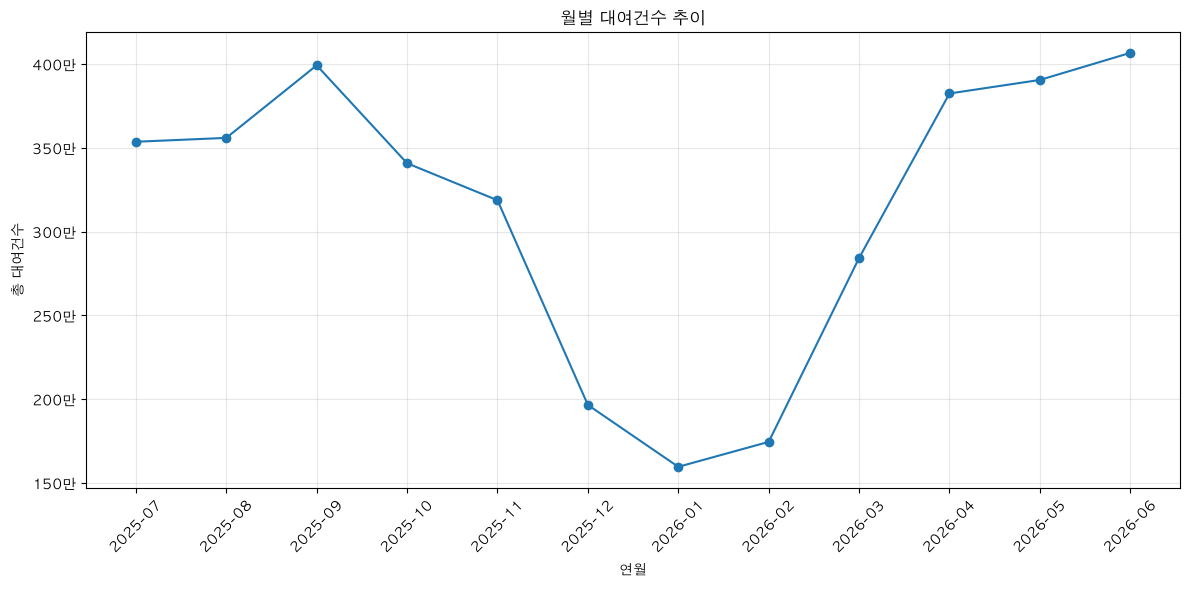

In [4]:
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

rental["대여일자"] = pd.to_datetime(rental["대여일자"])
rental["연월"] = rental["대여일자"].dt.to_period("M")
monthly = rental.groupby("연월")["대여건수"].sum().reset_index()
monthly["연월"] = monthly["연월"].astype(str)

def man_formatter(x, pos):
    return f"{x/10000:.0f}만"

plt.figure(figsize=(12, 6))
plt.plot(monthly["연월"], monthly["대여건수"], marker="o")

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(man_formatter))

plt.title("월별 대여건수 추이")
plt.xlabel("연월")
plt.ylabel("총 대여건수")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 따릉이 이용자들의 평균 이용시간

이용시간을 평균낼 때 .mean() 이 아니라 ‘이용시간(분)*대여건수 / 대여건수’로 같은 이용시간을 책정해 같은 행에 대여건수(이용자 수)가 다른 행을 고려하지 않고 평균 내버리는 경우 방지함

In [14]:
df = pd.read_csv("초급 프로젝트 [따릉이 데이터]/분석에 쓰일 데이터/시간대별 이용정보.csv")
df

,대여일자,시간대,대여구분코드,성별,연령대,대여건수,운동량,탄소량,이동거리(M),이용시간(분)
0,2025-07-01,0,정기권(회원),NaN,10대 이하,1,15.83,0.14,615.10,5
1,2025-07-01,0,정기권(회원),NaN,20대,1,9.81,0.09,381.15,4
2,2025-07-01,0,정기권(회원),NaN,20대,2,31.36,0.33,1393.80,8
3,2025-07-01,0,정기권(회원),NaN,20대,1,79.58,0.72,3091.62,16
4,2025-07-01,0,정기권(회원),NaN,20대,2,76.78,0.69,2982.88,38
...,...,...,...,...,...,...,...,...,...,...
34247549,2026-06-30,23,일일권(회원)(3시간),여성,20대,1,72.91,0.66,2832.43,82
34247550,2026-06-30,23,일일권(회원)(3시간),여성,30대,1,15.10,0.14,586.79,7
34247551,2026-06-30,23,일일권(회원)(3시간),남성,20대,1,77.21,0.70,2999.47,82
34247552,2026-06-30,23,일일권(회원)(3시간),남성,30대,1,15.02,0.14,583.45,2


In [27]:
df['연령대'] = df['연령대'].replace('10대 & 10대 이하', '10대 이하 & 10대')

In [28]:
df['연령대'].unique()

<ArrowStringArray>
['10대 이하 & 10대', '20대', '30대', '40대', '50대', '60대', '70대이상', '기타']
Length: 8, dtype: str

In [37]:
df['대여일자'] = pd.to_datetime(df['대여일자'])

# 대여건수만큼 중복된 값이므로 (값 × 건수)로 가중치를 반영해야 정확한 평균/합계가 나옴
df['이용시간_가중'] = df['이용시간(분)'] * df['대여건수']
df['이동거리_가중'] = df['이동거리(M)'] * df['대여건수']

In [34]:
df['이용시간(분)'].describe()

count    3.424755e+07
mean     2.278843e+01
std      3.173930e+01
min      0.000000e+00
25%      6.000000e+00
50%      1.200000e+01
75%      2.700000e+01
max      6.597700e+04
Name: 이용시간(분), dtype: float64

/var/folders/k2/31ny17_j7lz46tv634mjq4h40000gn/T/ipykernel_19953/3505819104.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


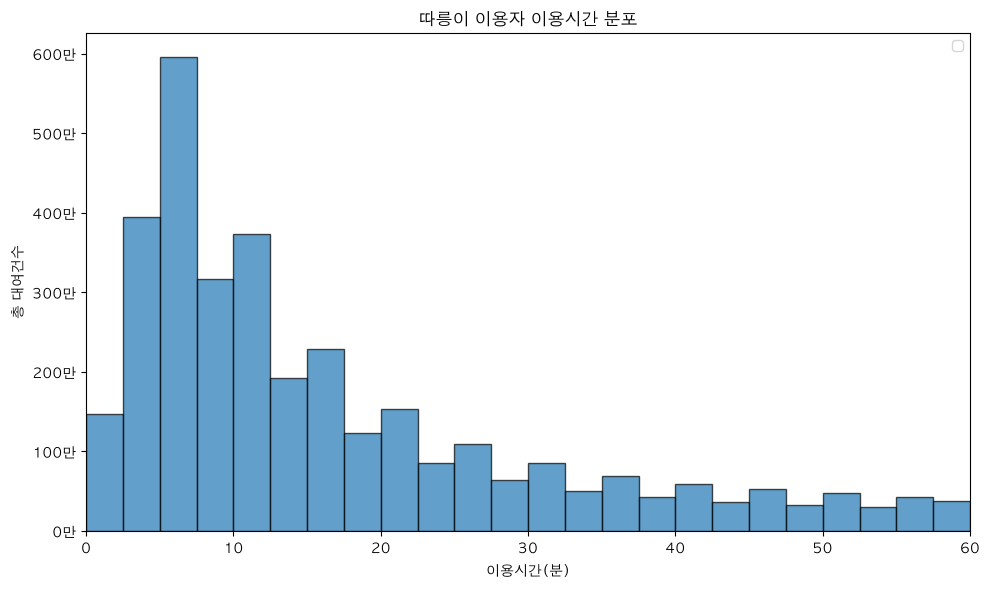

전체 이용자 평균 이용시간: 25.25분


In [6]:
# 평균 이용시간 분포
def man_formatter(x, pos):
    return f"{x/10000:.0f}만"

plt.figure(figsize=(10, 6))
plt.hist(df["이용시간(분)"], weights=df["대여건수"],
          bins=24, range=(0, 60),
          edgecolor="black", alpha=0.7)

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(man_formatter))

plt.xticks(range(0, 61, 10))
plt.xlim(0, 60)
plt.xlabel("이용시간(분)")
plt.ylabel("총 대여건수")
plt.title("따릉이 이용자 이용시간 분포")
plt.legend()
plt.tight_layout()
plt.show()

overall_avg = (df["이용시간(분)"] * df["대여건수"]).sum() / df["대여건수"].sum()
print(f"전체 이용자 평균 이용시간: {overall_avg:.2f}분")

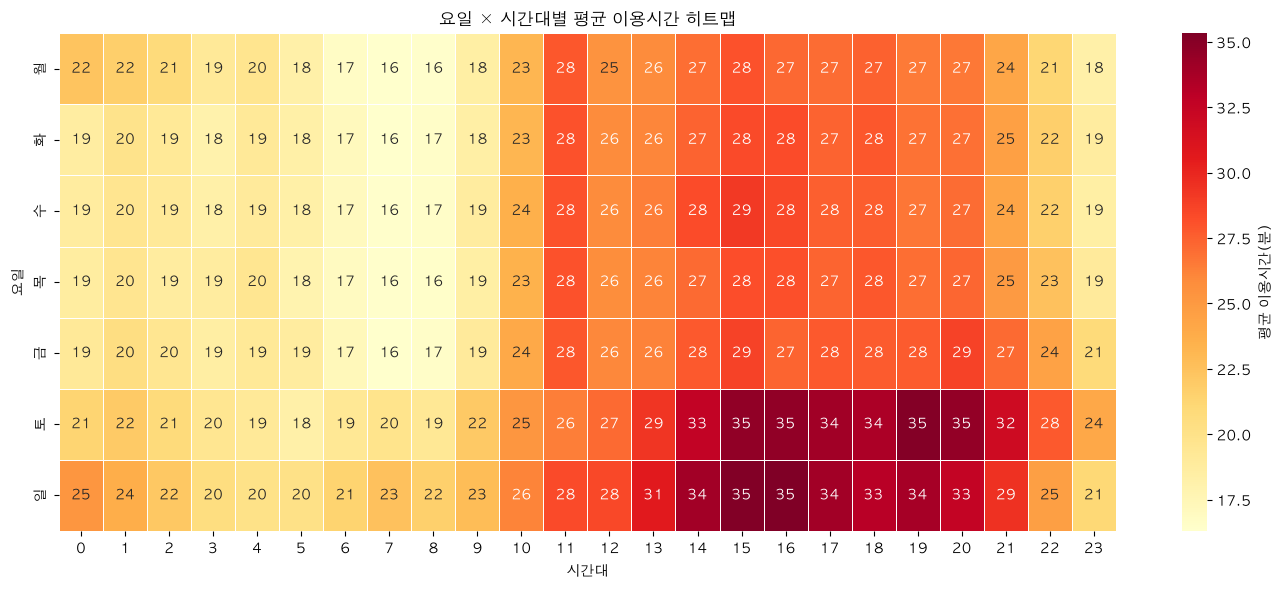

평일 평균 이용시간: 23.84
주말 평균 이용시간: 29.6


In [44]:
# 요일 × 시간대별 평균 이용시간 히트맵

df["대여일자"] = pd.to_datetime(df["대여일자"])
weekday_order = ["월", "화", "수", "목", "금", "토", "일"]
df["요일"] = df["대여일자"].dt.dayofweek.map(dict(zip(range(7), weekday_order)))

def weighted_avg(x):
    return (x["이용시간(분)"] * x["대여건수"]).sum() / x["대여건수"].sum()

grouped = df.groupby(["요일", "시간대"]).apply(weighted_avg).reset_index(name="평균이용시간")
pivot = grouped.pivot(index="요일", columns="시간대", values="평균이용시간").reindex(weekday_order)
annot_data = pivot.round(0).astype(int)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap="YlOrRd", annot=annot_data, fmt="d", linewidths=0.5,
    cbar_kws={"label": "평균 이용시간(분)"})
plt.title("요일 × 시간대별 평균 이용시간 히트맵")
plt.xlabel("시간대")
plt.ylabel("요일")
plt.tight_layout()
plt.show()

summary = df.groupby('평일주말').agg(
    총이용시간=('이용시간_가중', 'sum'),
    총건수=('대여건수', 'sum')
)
summary['평균이용시간(분)'] = summary['총이용시간'] / summary['총건수']
print("평일 평균 이용시간:", round(summary.loc['평일','평균이용시간(분)'], 2))
print("주말 평균 이용시간:", round(summary.loc['주말','평균이용시간(분)'], 2))

## 사용자 분석 EDA

#### 회원 vs 비회원 비중

In [1]:
import pandas as pd

df_raw = pd.read_csv("초급 프로젝트 [따릉이 데이터]/분석에 쓰일 데이터/시간대별 이용정보.csv")
df_raw['대여건수'] = pd.to_numeric(df_raw['대여건수'], errors='coerce')

def get_membership(code):
    if '비회원' in code:
        return '비회원'
    elif '회원' in code:
        return '회원'
    else:
        return '기타(가족권 등)'

df_raw['회원구분'] = df_raw['대여구분코드'].apply(get_membership)

# 원본 코드 종류가 어떻게 분류됐는지 확인 (가족권처럼 회원/비회원 표기가 없는 코드가 있는지 체크)
print(df_raw[['대여구분코드', '회원구분']].drop_duplicates().sort_values('회원구분'))

membership = df_raw.groupby('회원구분').agg(
    대여건수=('대여건수', 'sum')
).reset_index()

membership['비율(%)'] = membership['대여건수'] / membership['대여건수'].sum() * 100
membership.to_csv("10_회원비회원_구성비율.csv", index=False)
print(membership)

                 대여구분코드 회원구분
1852           일일권(비회원)  비회원
14370480  일일권(비회원)(3시간)  비회원
0               정기권(회원)   회원
1270            일일권(회원)   회원
7355            가족권(회원)   회원
73226      가족권(회원)(2시간)   회원
8505651    가족권(회원)(3시간)   회원
12403193   일일권(회원)(3시간)   회원
  회원구분      대여건수      비율(%)
0  비회원    315652   0.842072
1   회원  37169520  99.157928


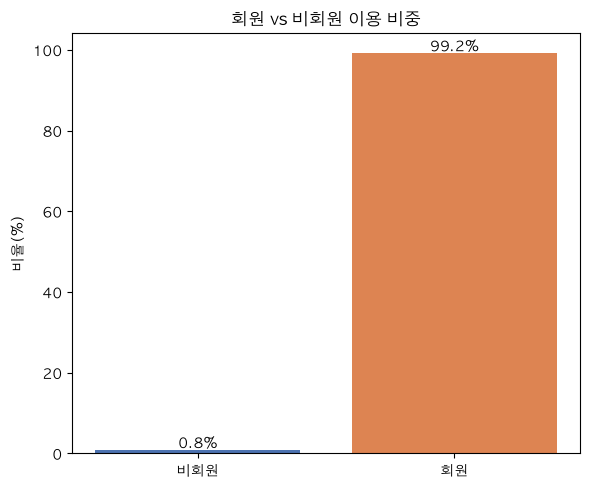

In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# macOS 기본 한글 폰트로 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
bars = plt.bar(membership['회원구분'], membership['비율(%)'], color=['#4C72B0','#DD8452','#55A868'])
plt.title('회원 vs 비회원 이용 비중')
plt.ylabel('비율(%)')
for bar, pct in zip(bars, membership['비율(%)']):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{pct:.1f}%', ha='center')
plt.tight_layout()
plt.show()

#### 정기권 vs 일일권 vs 가족권 비중

In [7]:
import pandas as pd

df_raw = pd.read_csv("초급 프로젝트 [따릉이 데이터]/분석에 쓰일 데이터/시간대별 이용정보.csv")
df_raw['대여건수'] = pd.to_numeric(df_raw['대여건수'], errors='coerce')

def get_plan_type(code):
    if '정기권' in code:
        return '정기권'
    elif '일일권' in code:
        return '일일권'
    elif '가족권' in code:
        return '가족권'
    else:
        return '기타'

df_raw['요금제유형'] = df_raw['대여구분코드'].apply(get_plan_type)

# 분류가 제대로 됐는지 확인 (혹시 '기타'로 빠지는 코드가 있는지 체크)
print(df_raw[['대여구분코드', '요금제유형']].drop_duplicates().sort_values('요금제유형'))

plan_summary = df_raw.groupby('요금제유형').agg(
    대여건수=('대여건수', 'sum')
).reset_index()

plan_summary['비율(%)'] = plan_summary['대여건수'] / plan_summary['대여건수'].sum() * 100
plan_summary.to_csv("11_요금제유형별_구성비율.csv", index=False)
print(plan_summary)

                 대여구분코드 요금제유형
7355            가족권(회원)   가족권
73226      가족권(회원)(2시간)   가족권
8505651    가족권(회원)(3시간)   가족권
1270            일일권(회원)   일일권
1852           일일권(비회원)   일일권
12403193   일일권(회원)(3시간)   일일권
14370480  일일권(비회원)(3시간)   일일권
0               정기권(회원)   정기권
  요금제유형      대여건수      비율(%)
0   가족권     68802   0.183545
1   일일권   6618724  17.656912
2   정기권  30797646  82.159543


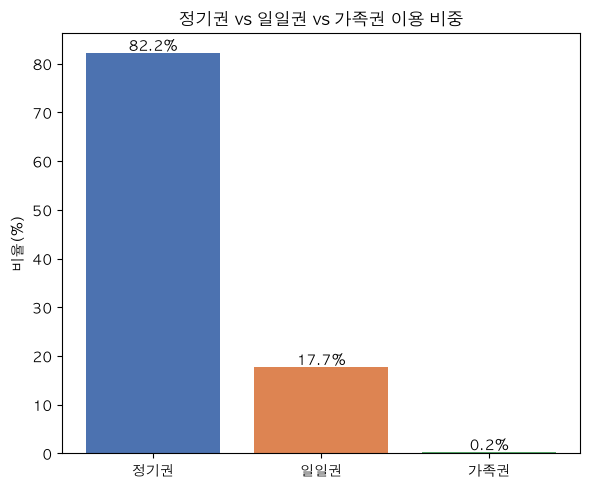

In [8]:
import matplotlib.pyplot as plt

order = ['정기권', '일일권', '가족권', '기타']
plan_summary_sorted = plan_summary.set_index('요금제유형').reindex([o for o in order if o in plan_summary['요금제유형'].values]).reset_index()

plt.figure(figsize=(6,5))
bars = plt.bar(plan_summary_sorted['요금제유형'], plan_summary_sorted['비율(%)'],
                color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.title('정기권 vs 일일권 vs 가족권 이용 비중')
plt.ylabel('비율(%)')
for bar, pct in zip(bars, plan_summary_sorted['비율(%)']):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{pct:.1f}%', ha='center')
plt.tight_layout()
plt.show()

#### 1. 남성 vs 여성 이용량 비교

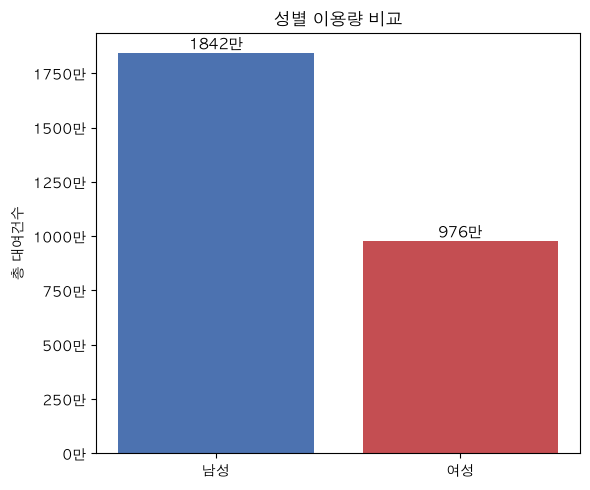

In [29]:
def man_formatter(x, pos):
    return f"{x/10000:.0f}만"

gender_stats = df.dropna(subset=["성별"]).groupby("성별")["대여건수"].sum()
colors = ["#4C72B0" if g == "남성" else "#C44E52" for g in gender_stats.index]

plt.figure(figsize=(6, 5))
bars = plt.bar(gender_stats.index, gender_stats.values, color=colors)

# 막대 위에 값 표시 (만 단위)
for bar, val in zip(bars, gender_stats.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + max(gender_stats.values)*0.01,
              f"{val/10000:.0f}만", ha='center', fontsize=11)

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(man_formatter))
plt.title("성별 이용량 비교")
plt.ylabel("총 대여건수")
plt.tight_layout()
plt.show()

#### 2. 연령대별 이용량 비교

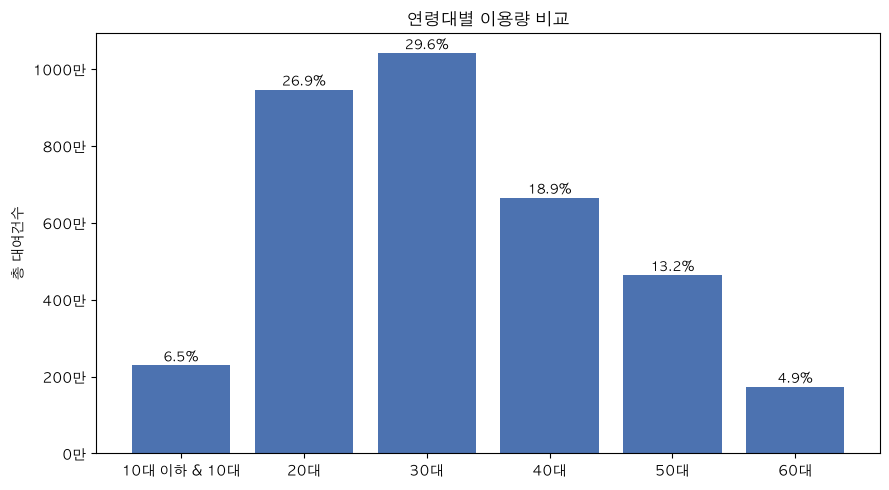

In [29]:
def man_formatter(x, pos):
    return f"{x/10000:.0f}만"

age_order = ["10대 이하 & 10대", "20대", "30대", "40대", "50대", "60대", "70대 이상"]
age_stats = df.groupby("연령대")["대여건수"].sum().reindex(age_order)

total = age_stats.sum()

plt.figure(figsize=(9, 5))
bars = plt.bar(age_stats.index, age_stats.values, color="#4C72B0")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(man_formatter))
plt.title("연령대별 이용량 비교")
plt.ylabel("총 대여건수")

# 막대 위에 비율(%)만 표시
for bar, value in zip(bars, age_stats.values):
    pct = value / total * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()

#### 3. 요일별 이동거리 비교 (건당 평균 이동거리)

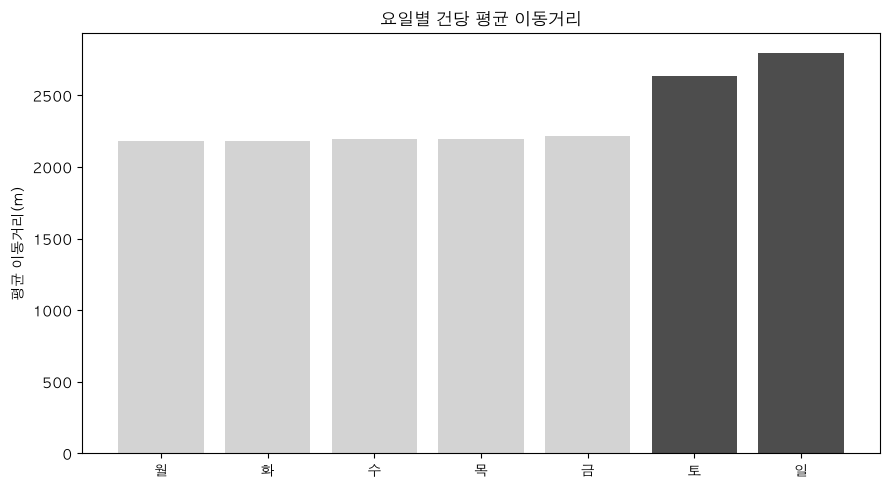

In [10]:
distance_stats = df.groupby("요일").apply(
    lambda x: x["이동거리(M)"].sum() / x["대여건수"].sum()
).reindex(weekday_order)

colors = ["#D3D3D3"]*5 + ["#4D4D4D"]*2 
plt.figure(figsize=(9, 5))
plt.bar(distance_stats.index, distance_stats.values, color=colors)
plt.title("요일별 건당 평균 이동거리")
plt.ylabel("평균 이동거리(m)")
plt.tight_layout()
plt.show()

#### 4. 요금제(대여구분코드)별 이용량 분포

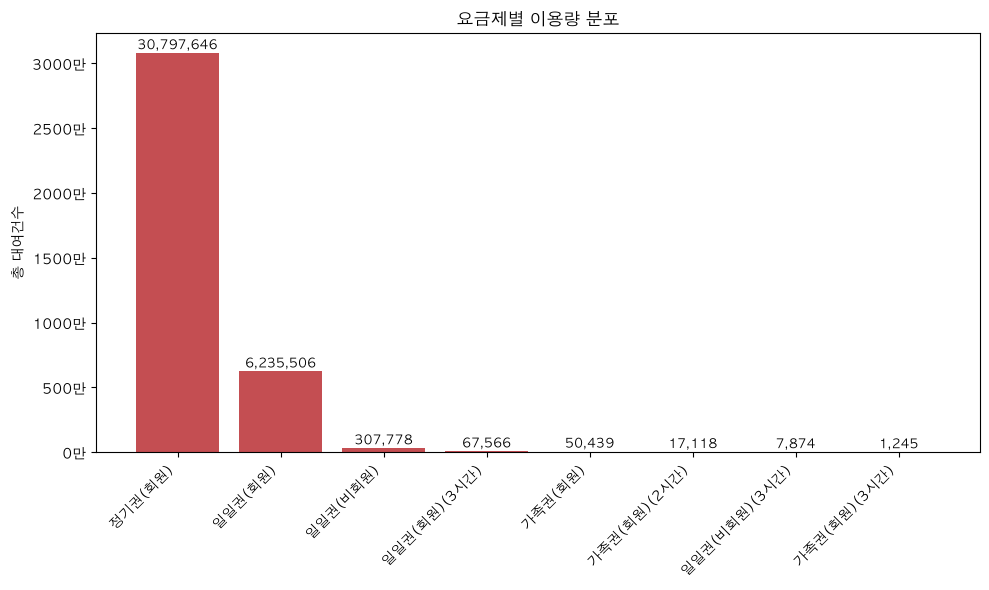

정기권(회원): 30,797,646건 (82.160%)
일일권(회원): 6,235,506건 (16.635%)
일일권(비회원): 307,778건 (0.821%)
일일권(회원)(3시간): 67,566건 (0.180%)
가족권(회원): 50,439건 (0.135%)
가족권(회원)(2시간): 17,118건 (0.046%)
일일권(비회원)(3시간): 7,874건 (0.021%)
가족권(회원)(3시간): 1,245건 (0.003%)


In [11]:
def man_formatter(x, pos):
    return f"{x/10000:.0f}만"

plan_stats = df.groupby("대여구분코드")["대여건수"].sum().sort_values(ascending=False)
total = plan_stats.sum()

plt.figure(figsize=(10, 6))
bars = plt.bar(plan_stats.index, plan_stats.values, color="#C44E52")

for bar, value in zip(bars, plan_stats.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
              f"{value:,.0f}", ha="center", va="bottom", fontsize=9)

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(man_formatter))
plt.title("요금제별 이용량 분포")
plt.ylabel("총 대여건수")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

for plan, value in plan_stats.items():
    pct = value / total * 100
    print(f"{plan}: {value:,.0f}건 ({pct:.3f}%)")

#### 5. 이용시간 × 요금제 (요금제별 평균 이용시간)

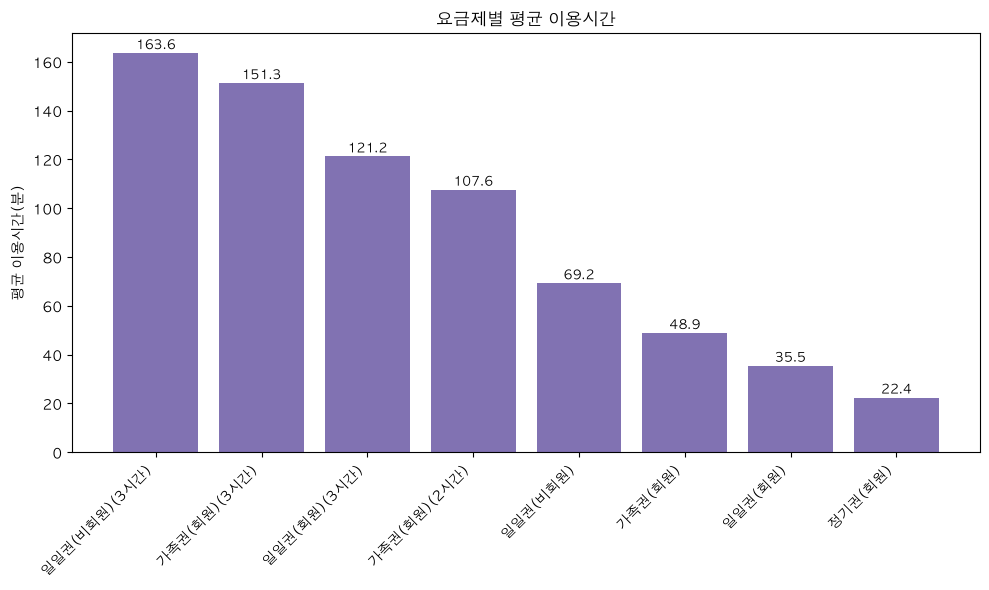

In [12]:
def weighted_avg(x):
    return (x["이용시간(분)"] * x["대여건수"]).sum() / x["대여건수"].sum()

plan_time = df.groupby("대여구분코드").apply(weighted_avg).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(plan_time.index, plan_time.values, color="#8172B2")

for bar, value in zip(bars, plan_time.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
              f"{value:.1f}", ha="center", va="bottom", fontsize=9)

plt.title("요금제별 평균 이용시간")
plt.ylabel("평균 이용시간(분)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### 6. 이용요일 × 요금제

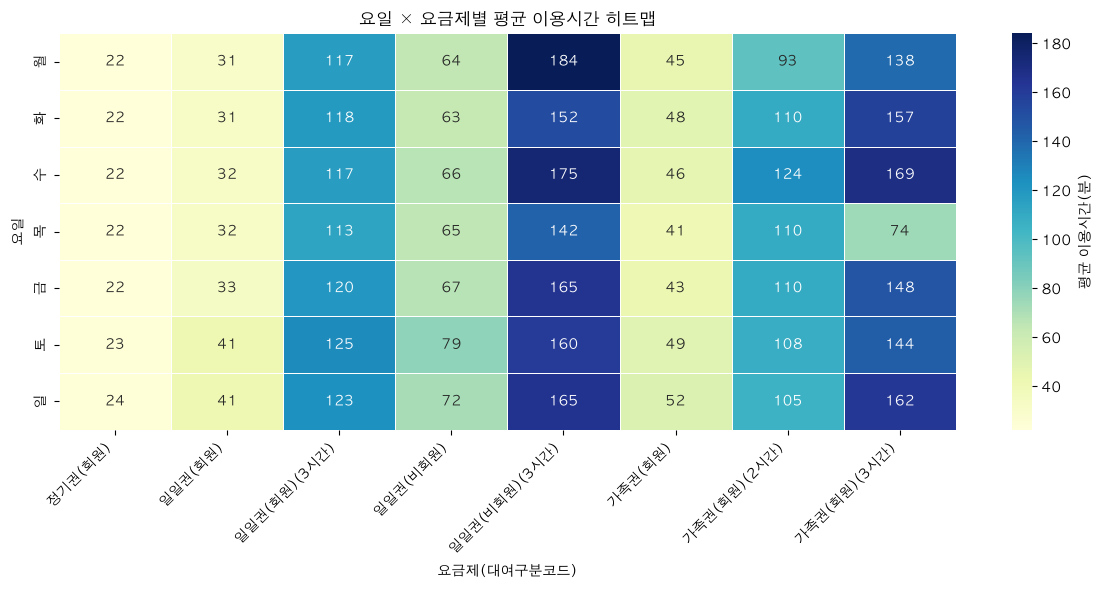

In [13]:
plan_order = ["정기권(회원)", "일일권(회원)", "일일권(회원)(3시간)",
              "일일권(비회원)", "일일권(비회원)(3시간)",
              "가족권(회원)", "가족권(회원)(2시간)", "가족권(회원)(3시간)"]

grouped = df.groupby(["요일", "대여구분코드"]).apply(weighted_avg).reset_index(name="평균이용시간")
pivot = grouped.pivot(index="요일", columns="대여구분코드", values="평균이용시간").reindex(weekday_order)[plan_order]
annot_data = pivot.round(0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="YlGnBu", annot=annot_data, fmt=".0f", linewidths=0.5,
            cbar_kws={"label": "평균 이용시간(분)"})
plt.title("요일 × 요금제별 평균 이용시간 히트맵")
plt.xlabel("요금제(대여구분코드)")
plt.ylabel("요일")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### 7. 이용시간,이동거리와 운동량,탄소량간의 관계

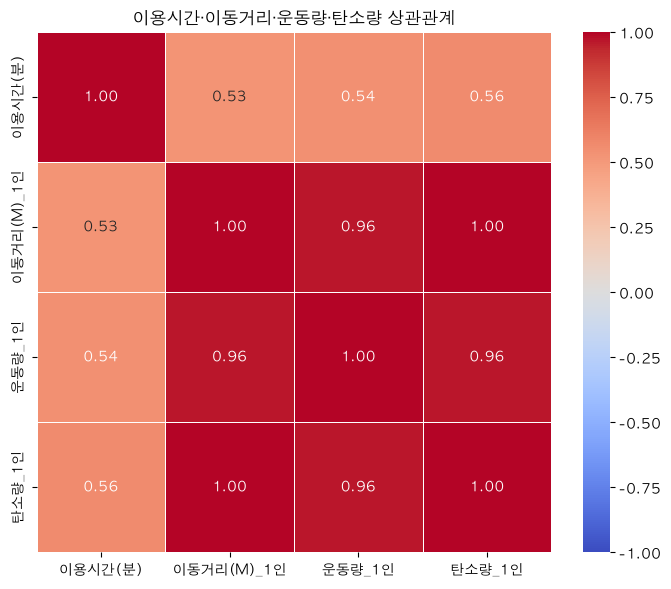

In [14]:
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

df_per = df.copy()

for col in ["이동거리(M)", "운동량", "탄소량", "대여건수", "이용시간(분)"]:
    df_per[col] = pd.to_numeric(
        df_per[col].astype(str).str.replace(",", ""), errors="coerce"
    )

df_per["이동거리(M)_1인"] = df_per["이동거리(M)"] / df_per["대여건수"]
df_per["운동량_1인"] = df_per["운동량"] / df_per["대여건수"]
df_per["탄소량_1인"] = df_per["탄소량"] / df_per["대여건수"]

sample = df_per.sample(n=50000, random_state=42)


corr_cols = ["이용시간(분)", "이동거리(M)_1인", "운동량_1인", "탄소량_1인"]
corr_matrix = df_per[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5)
plt.title("이용시간·이동거리·운동량·탄소량 상관관계")
plt.tight_layout()
plt.show()

#### 8. 외국인 대여정보

In [15]:
foreigner_df1 = pd.read_csv("초급 프로젝트 [따릉이 데이터]/분석에 쓰일 데이터/외국인 대여.csv")
foreigner_df2 = pd.read_csv("초급 프로젝트 [따릉이 데이터]/분석에 쓰일 데이터/대여이력.csv")
print(foreigner_df1.head(3))
print(foreigner_df2.head(1))

         대여일자  대여건수  반납건수
0  2025-07-01     0     1
1  2025-07-01     1     1
2  2025-07-01     1     0
         대여일자  이용시간(분)  이동거리(M)  연령대  성별 이용자종류  시간대
0  2025-07-01        2    500.0  20대  남성   NaN    0


In [16]:
foreigner_df1 = foreigner_df1.drop(columns=["반납건수"])
print(foreigner_df1.head(1))
foreigner_df2 = foreigner_df2[foreigner_df2["이용자종류"] == "외국인"]
print(foreigner_df2.head(1))

         대여일자  대여건수
0  2025-07-01     0
           대여일자  이용시간(분)  이동거리(M)  연령대   성별 이용자종류  시간대
445  2025-07-01       11   1490.0  NaN  NaN   외국인    0


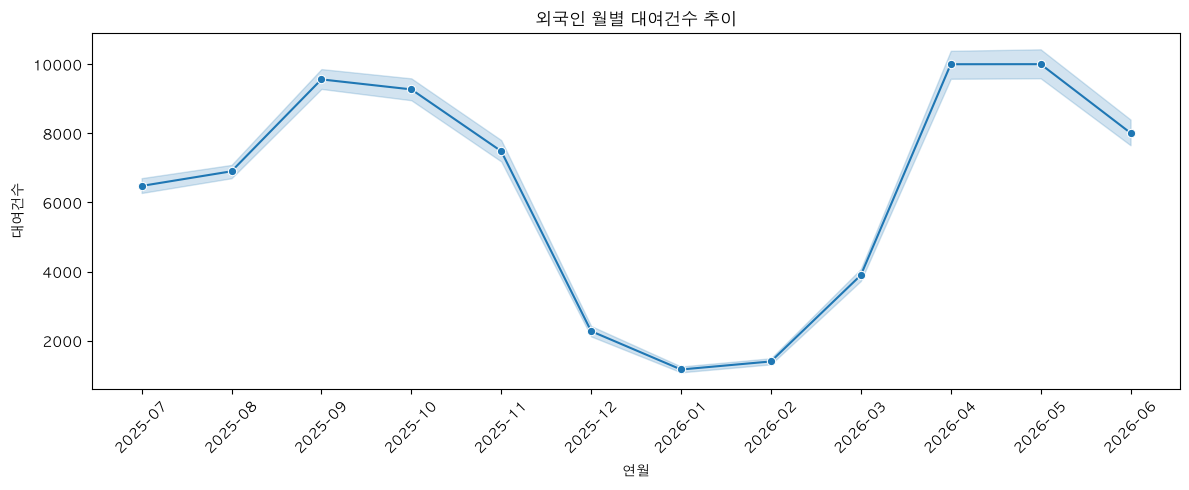

In [17]:
# 대여 추이 확인
foreigner_df1["대여일자"] = pd.to_datetime(foreigner_df1["대여일자"])
foreigner_df1["연월"] = foreigner_df1["대여일자"].dt.to_period("M").astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=foreigner_df1, x="연월", y="대여건수", estimator="sum", marker="o")
plt.title("외국인 월별 대여건수 추이")
plt.xlabel("연월")
plt.ylabel("대여건수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

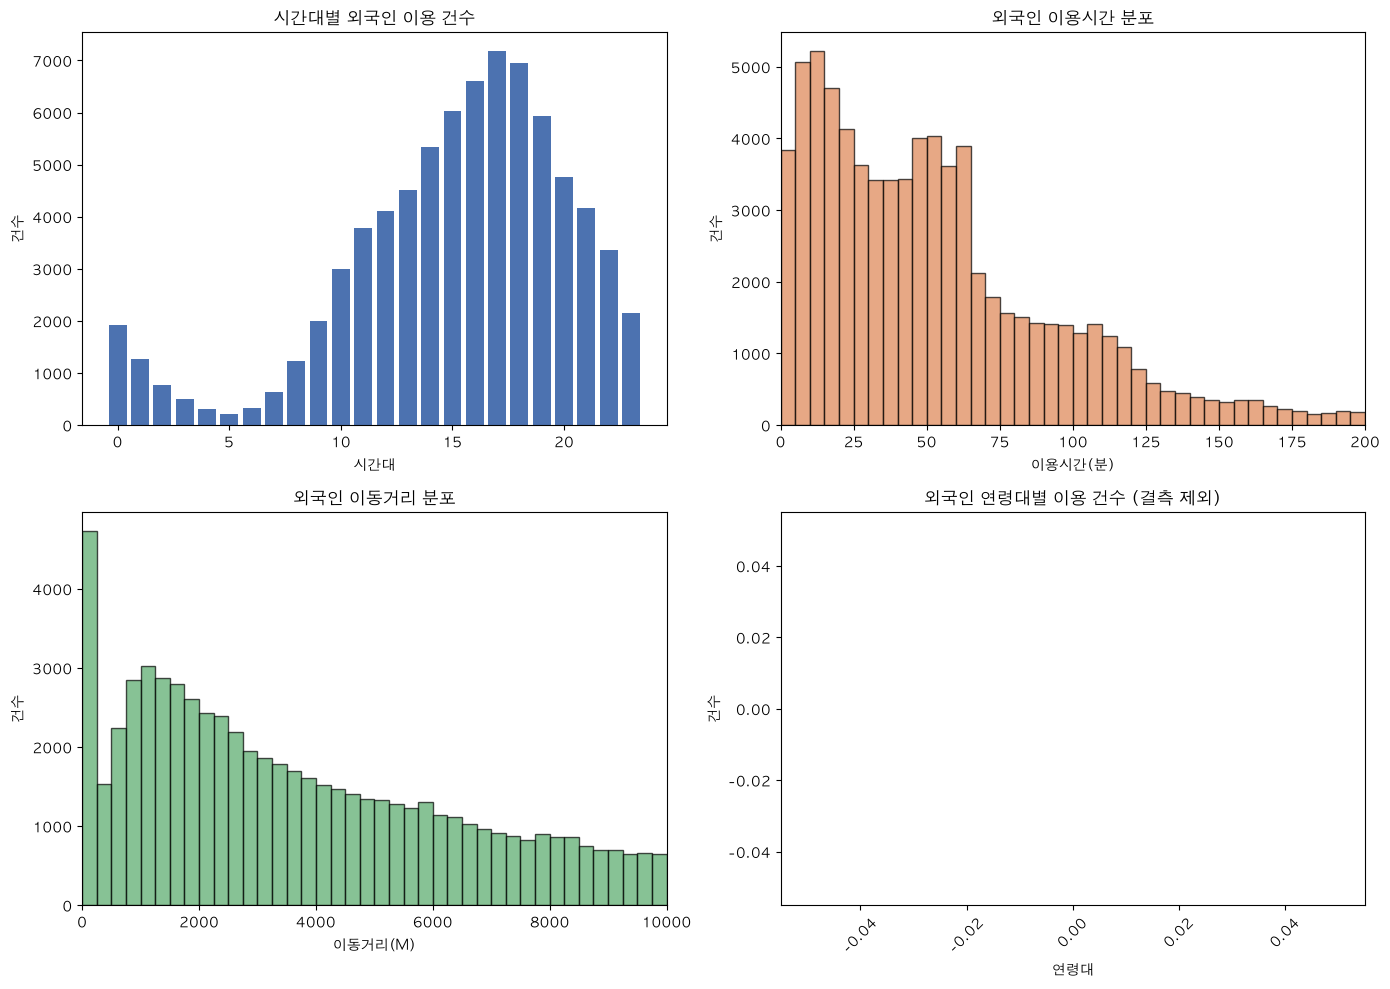

평균 이용시간: 65.9분
평균 이동거리: 5947.6m


In [18]:
# (1) 시간대별 외국인 이용 건수
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) 시간대별 외국인 이용 건수
hourly = foreigner_df2.groupby("시간대").size()
axes[0, 0].bar(hourly.index, hourly.values, color="#4C72B0")
axes[0, 0].set_title("시간대별 외국인 이용 건수")
axes[0, 0].set_xlabel("시간대")
axes[0, 0].set_ylabel("건수")

# (2) 이용시간 분포
axes[0, 1].hist(foreigner_df2["이용시간(분)"], bins=40, range=(0, 200),
                  color="#DD8452", edgecolor="black", alpha=0.7)
axes[0, 1].set_title("외국인 이용시간 분포")
axes[0, 1].set_xlabel("이용시간(분)")
axes[0, 1].set_ylabel("건수")
axes[0, 1].set_xlim(0, 200)

# (3) 이동거리 분포
axes[1, 0].hist(foreigner_df2["이동거리(M)"].dropna(), bins=40, range=(0, 10000),
                  color="#55A868", edgecolor="black", alpha=0.7)
axes[1, 0].set_title("외국인 이동거리 분포")
axes[1, 0].set_xlabel("이동거리(M)")
axes[1, 0].set_ylabel("건수")
axes[1, 0].set_xlim(0, 10000)

# (4) 연령대별 이용 건수 (결측치 제외)
age_counts = foreigner_df2["연령대"].value_counts(dropna=True)
axes[1, 1].bar(age_counts.index, age_counts.values, color="#8172B2")
axes[1, 1].set_title("외국인 연령대별 이용 건수 (결측 제외)")
axes[1, 1].set_xlabel("연령대")
axes[1, 1].set_ylabel("건수")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"평균 이용시간: {foreigner_df2['이용시간(분)'].mean():.1f}분")
print(f"평균 이동거리: {foreigner_df2['이동거리(M)'].mean():.1f}m")

#### 9. 신규가입자

In [19]:
new_df = pd.read_csv("초급 프로젝트 [따릉이 데이터]/분석에 쓰일 데이터/신규가입자.csv")
new_df = new_df.drop(columns=["Unnamed: 0"])
new_df['성별'] = new_df['성별'].map({'F': '여성', 'M': '남성'})
new_df 

,가입일자,연령대,성별,가입건수
0,2025-07-01,10대,여성,64
1,2025-07-01,10대,남성,84
2,2025-07-01,20대,여성,124
3,2025-07-01,20대,남성,173
4,2025-07-01,30대,여성,74
...,...,...,...,...
5726,2026-06-30,60대,남성,29
5727,2026-06-30,70대이상,여성,1
5728,2026-06-30,70대이상,남성,4
5729,2026-06-30,기타,여성,24


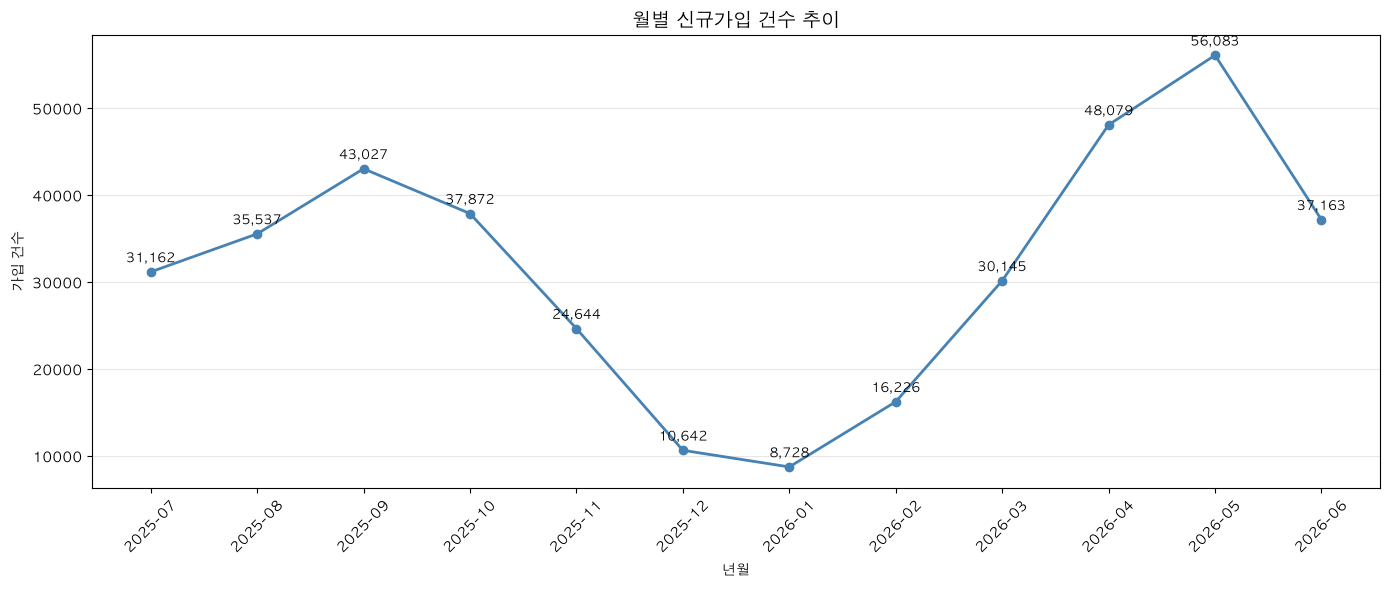

In [20]:
# 월별 가입건수 추이

new_df['가입일자'] = pd.to_datetime(new_df['가입일자'])

daily_total = new_df.groupby('가입일자')['가입건수'].sum().reset_index()

# 가입일자를 datetime으로 변환 후 년-월 컬럼 생성
daily_total['가입일자'] = pd.to_datetime(daily_total['가입일자'])
daily_total['년월'] = daily_total['가입일자'].dt.to_period('M').astype(str)

# 월별 합계로 재집계
monthly_total = daily_total.groupby('년월')['가입건수'].sum().reset_index()

# 라인차트
plt.figure(figsize=(14, 6))
plt.plot(monthly_total['년월'], monthly_total['가입건수'], marker='o', linewidth=2, color='steelblue')

for x, y in zip(monthly_total['년월'], monthly_total['가입건수']):
    plt.text(x, y + max(monthly_total['가입건수'])*0.02, f'{y:,}', ha='center', fontsize=9)

plt.title('월별 신규가입 건수 추이', fontsize=14)
plt.xlabel('년월')
plt.ylabel('가입 건수')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

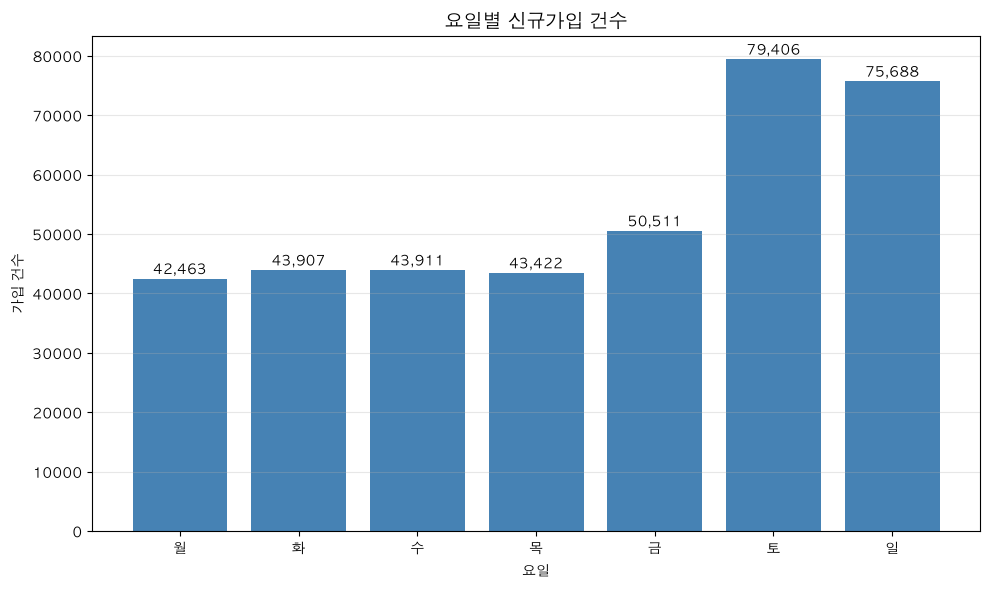

In [21]:
# 요일별 신규가입 건수 비교
new_df['가입일자'] = pd.to_datetime(new_df['가입일자'])

# 요일 컬럼 생성 (월=0 ~ 일=6)
new_df['요일'] = new_df['가입일자'].dt.dayofweek

# 요일 순서와 한글 라벨 지정
weekday_order = [0, 1, 2, 3, 4, 5, 6]
weekday_labels = ['월', '화', '수', '목', '금', '토', '일']

# 요일별 가입건수 합계
weekday_total = new_df.groupby('요일')['가입건수'].sum().reindex(weekday_order)

# 막대그래프
plt.figure(figsize=(10, 6))
bars = plt.bar(weekday_labels, weekday_total.values, color='steelblue')

# 값 라벨 표시
for bar, val in zip(bars, weekday_total.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + max(weekday_total.values)*0.01,
              f'{val:,}', ha='center', fontsize=10)

plt.title('요일별 신규가입 건수', fontsize=14)
plt.xlabel('요일')
plt.ylabel('가입 건수')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

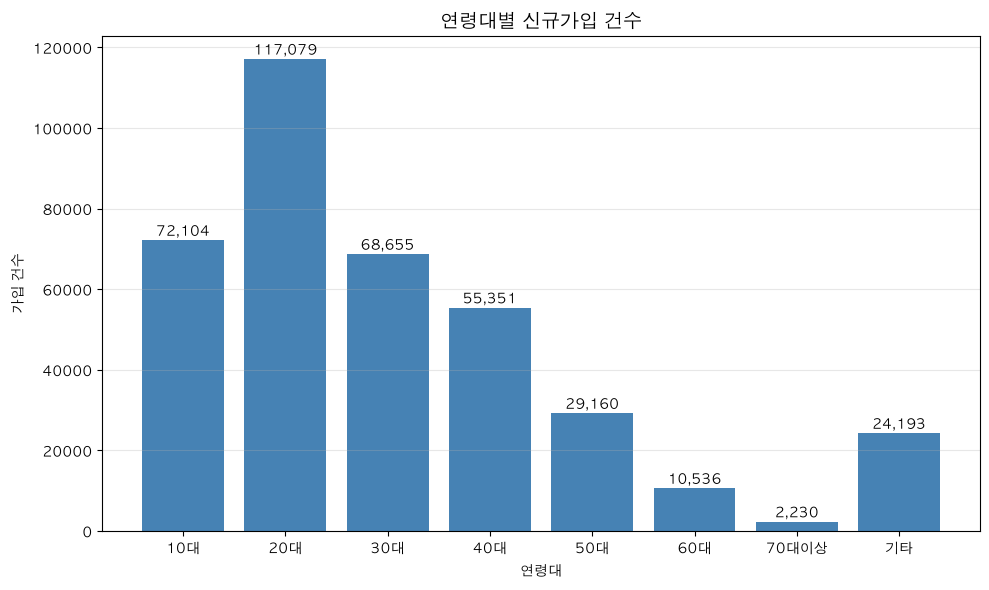

In [35]:
# ── 1. 연령대별 전체 가입건수 (막대그래프) ──
age_total = new_df.groupby('연령대')['가입건수'].sum().reindex(age_order)

plt.figure(figsize=(10, 6))
bars = plt.bar(age_total.index, age_total.values, color='steelblue')
for bar, val in zip(bars, age_total.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + max(age_total.values)*0.01,
              f'{val:,}', ha='center', fontsize=10)

# 연령대 순서 지정
age_order = ['10대 이하', '20대', '30대', '40대', '50대', '60대', '70대이상', '기타']

plt.title('연령대별 신규가입 건수', fontsize=14)
plt.xlabel('연령대')
plt.ylabel('가입 건수')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

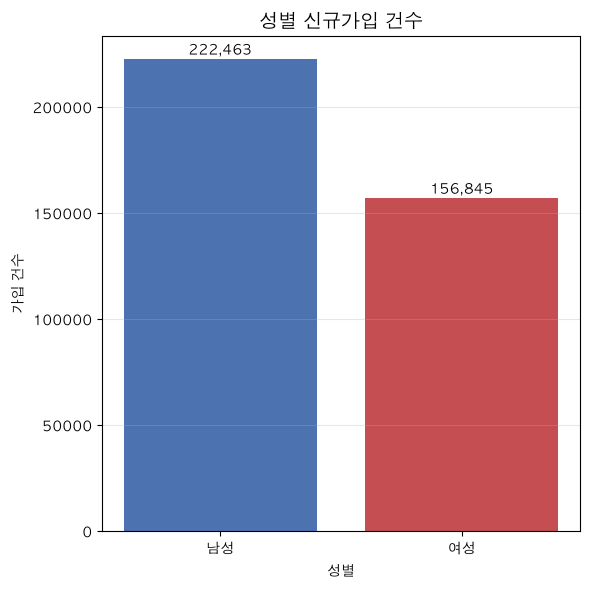

In [23]:
# ── 2. 성별 전체 가입건수 (막대그래프) ──
gender_total = new_df.groupby('성별')['가입건수'].sum()

plt.figure(figsize=(6, 6))
bars = plt.bar(gender_total.index, gender_total.values, color=['#4C72B0', '#C44E52'])
for bar, val in zip(bars, gender_total.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + max(gender_total.values)*0.01,
              f'{val:,}', ha='center', fontsize=10)
plt.title('성별 신규가입 건수', fontsize=14)
plt.xlabel('성별')
plt.ylabel('가입 건수')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

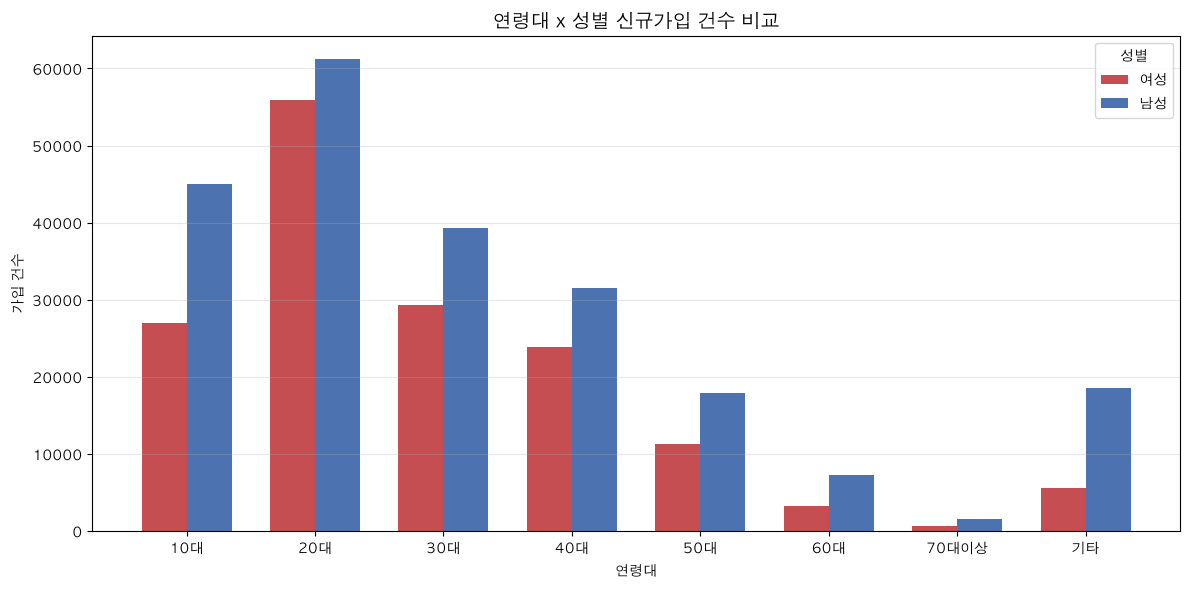

In [24]:
# ── 3. 연령대 x 성별 비교 (그룹 막대그래프) ──
pivot = new_df.pivot_table(index='연령대', columns='성별', values='가입건수', aggfunc='sum').reindex(age_order)

x = range(len(pivot.index))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar([i - width/2 for i in x], pivot['여성'], width, label='여성', color='#C44E52')
plt.bar([i + width/2 for i in x], pivot['남성'], width, label='남성', color='#4C72B0')

plt.xticks(list(x), pivot.index)
plt.title('연령대 x 성별 신규가입 건수 비교', fontsize=14)
plt.xlabel('연령대')
plt.ylabel('가입 건수')
plt.legend(title='성별')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

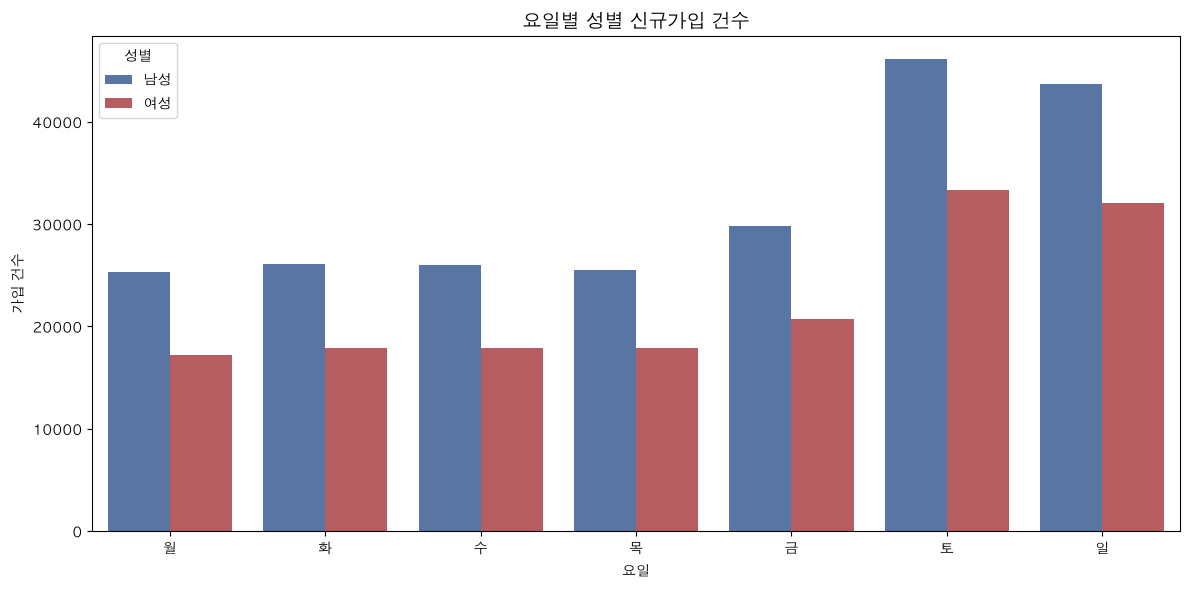

In [32]:
# 가입일자 전처리 & 요일 컬럼 생성
new_df['가입일자'] = pd.to_datetime(new_df['가입일자'])
new_df['요일'] = new_df['가입일자'].dt.dayofweek

weekday_order = [0, 1, 2, 3, 4, 5, 6]
weekday_labels = ['월', '화', '수', '목', '금', '토', '일']
new_df['요일명'] = new_df['요일'].map(dict(zip(weekday_order, weekday_labels)))
new_df['요일명'] = pd.Categorical(new_df['요일명'], categories=weekday_labels, ordered=True)

# 요일별 성별 집계
gender_weekday = new_df.groupby(['요일명', '성별'], observed=True)['가입건수'].sum().reset_index()

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(
    data=gender_weekday, x='요일명', y='가입건수', hue='성별',
    hue_order=['남성', '여성'],
    palette={'남성': '#4C72B0', '여성': '#C44E52'}
)
plt.title('요일별 성별 신규가입 건수', fontsize=14)
plt.xlabel('요일')
plt.ylabel('가입 건수')
plt.legend(title='성별')
plt.tight_layout()
plt.show()

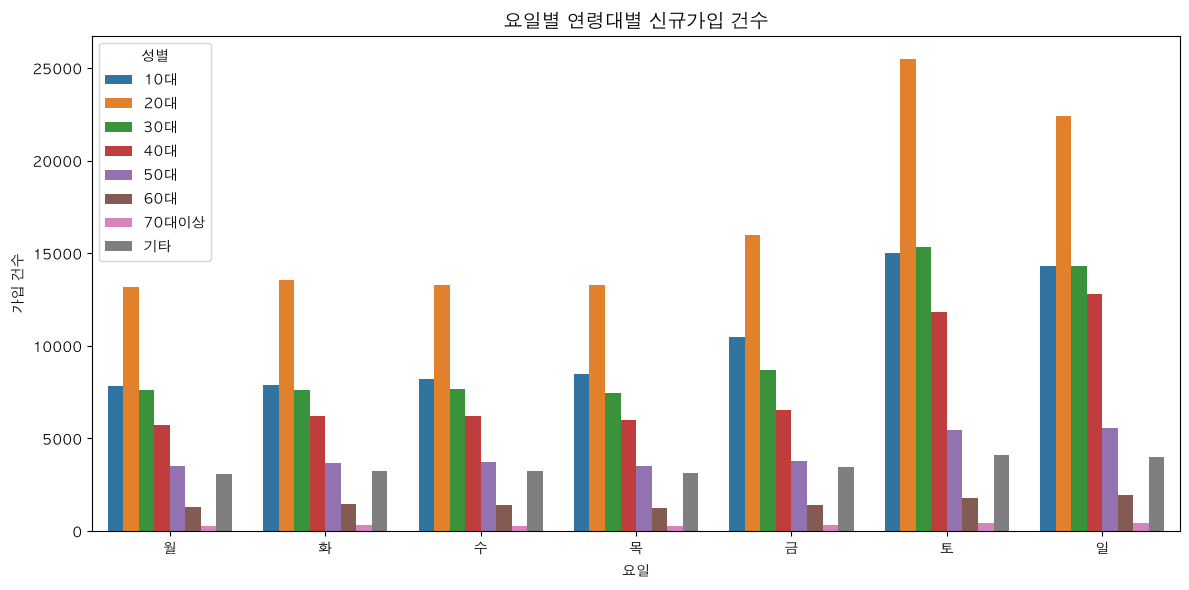

In [36]:
# 요일별 연령대 집계
gender_weekday = new_df.groupby(['요일명', '연령대'], observed=True)['가입건수'].sum().reset_index()

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(
    data=gender_weekday, x='요일명', y='가입건수', hue='연령대'
)
plt.title('요일별 연령대별 신규가입 건수', fontsize=14)
plt.xlabel('요일')
plt.ylabel('가입 건수')
plt.legend(title='성별')
plt.tight_layout()
plt.show()

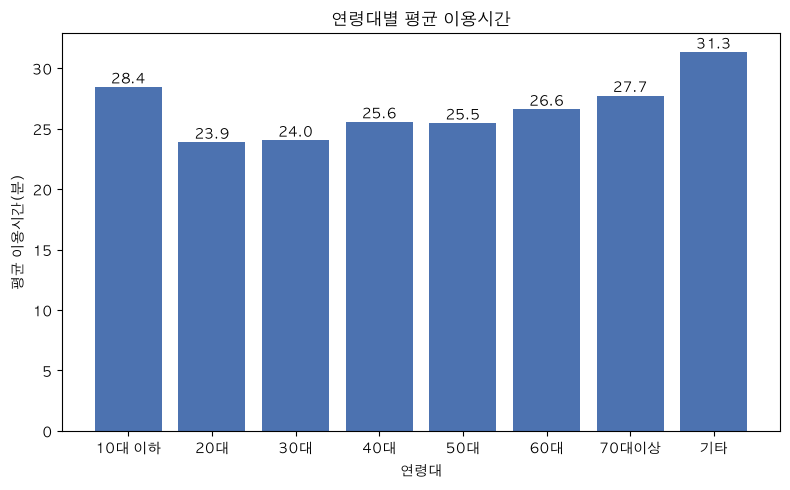

In [39]:
# 연령대별 평균 이용시간
age_summary = df.groupby('연령대').agg(
    총이용시간=('이용시간_가중', 'sum'),
    총건수=('대여건수', 'sum')
)
age_summary['평균이용시간(분)'] = age_summary['총이용시간'] / age_summary['총건수']

age_order = ['10대 이하', '20대', '30대', '40대', '50대', '60대', '70대이상', '기타']
age_summary = age_summary.reindex([a for a in age_order if a in age_summary.index])

plt.figure(figsize=(8,5))
bars = plt.bar(age_summary.index, age_summary['평균이용시간(분)'], color='#4C72B0')
plt.title('연령대별 평균 이용시간')
plt.xlabel('연령대')
plt.ylabel('평균 이용시간(분)')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.1f}', ha='center')
plt.tight_layout()
plt.show()

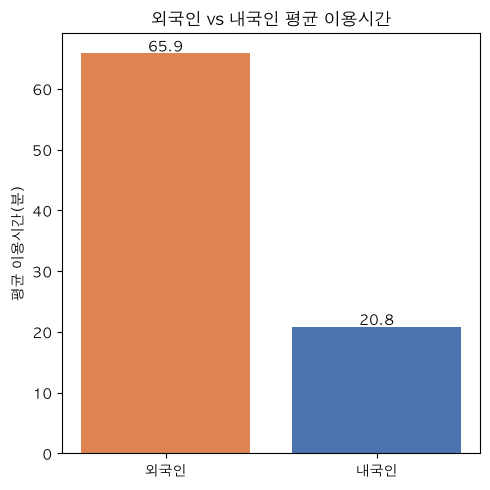

In [40]:
# 외국인 vs 내국인 평균 이용시간
history = pd.read_csv("초급 프로젝트 [따릉이 데이터]/분석에 쓰일 데이터/대여이력.csv")

foreign = history[history['이용자종류'] == '외국인']
domestic = history[history['이용자종류'] != '외국인']

comparison = pd.Series({
    '외국인': foreign['이용시간(분)'].mean(),
    '내국인': domestic['이용시간(분)'].mean()
})

plt.figure(figsize=(5,5))
bars = plt.bar(comparison.index, comparison.values, color=['#DD8452','#4C72B0'])
plt.title('외국인 vs 내국인 평균 이용시간')
plt.ylabel('평균 이용시간(분)')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.1f}', ha='center')
plt.tight_layout()
plt.show()

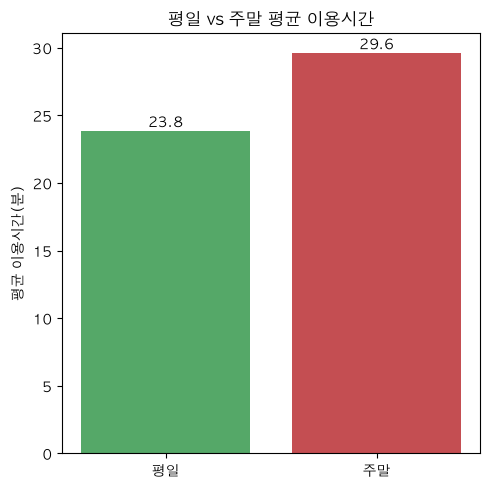

In [43]:
# 평일 vs 주말 '이동거리/이용시간' 비율
df['요일'] = df['대여일자'].dt.day_name()
df['평일주말'] = df['요일'].isin(['Saturday', 'Sunday']).map({True: '주말', False: '평일'})

time_summary = df.groupby('평일주말').agg(
    총이용시간=('이용시간_가중', 'sum'),
    총건수=('대여건수', 'sum')
)
time_summary['평균이용시간(분)'] = time_summary['총이용시간'] / time_summary['총건수']
time_summary = time_summary.reindex(['평일', '주말'])

plt.figure(figsize=(5,5))
bars = plt.bar(time_summary.index, time_summary['평균이용시간(분)'], color=['#55A868','#C44E52'])
plt.title('평일 vs 주말 평균 이용시간')
plt.ylabel('평균 이용시간(분)')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.1f}', ha='center')
plt.tight_layout()
plt.show()